"Streaming, redes sociales y conciertos: construcción empírica del éxito de un artista musical"
Autora Silvana Contreras
Mayo 2026


In [1]:
# !pip install pandas numpy matplotlib seaborn scikit-learn jupyter


In [2]:
import pandas as pd
import numpy as np

In [3]:
from pathlib import Path

# ============================================================
# Directorio único de guardado de gráficos y tablas del proyecto
# ============================================================

directorio_salidas_proyecto = Path(
    r"C:\Users\Silvana\Documents\Maestria_Exactas\taller_tesis_1\music_industry_social_live_code\graficos"
)

directorio_salidas_proyecto.mkdir(
    parents=True,
    exist_ok=True
)

print("Directorio de salida:", directorio_salidas_proyecto)
print("Existe:", directorio_salidas_proyecto.exists())

# ejemplo uso
# ruta_grafico_ranking_editorial = (
#     directorio_salidas_proyecto /
#     "ranking_editorial_lifts_top_bottom_trios.png"
# )

# plt.savefig(
#     ruta_grafico_ranking_editorial,
#     dpi=300,
#     bbox_inches="tight"
# )

Directorio de salida: C:\Users\Silvana\Documents\Maestria_Exactas\taller_tesis_1\music_industry_social_live_code\graficos
Existe: True


# levanto dataset

In [4]:
from pathlib import Path
import pandas as pd

df = pd.read_csv("dataset_4913_53.csv")
# df = pd.read_csv("dataset_7000_53.csv.csv")

print("Dimensiones:", df.shape)


Dimensiones: (4913, 53)


# dimensiones variables
creo tabla

In [5]:
# ============================================================
# Paso 2. Agrupación conceptual de variables
# Construcción de diccionario de variables
# ============================================================

id_cols = [
    "chartmetric_id",
    "artist_name"
]

metadata_cols = [
    "country",
    "country_short",
    "pronoun_title",
    "pronoun_short",
    "record_label",
    "major_record_label",
    "primary_genre",
    "genre_short",
    "band",
    "muerto_disuelto"
]

streaming_cols = [
    "sp_followers",
    "sp_monthly_listeners",
    "sp_popularity",
    "deezer_fans",
    "shazam_count",
    "pandora_lifetime_streams",
    "pandora_lifetime_stations_added"
]

playlist_cols = [
    "sp_playlist_total_reach",
    "num_sp_editorial_playlists",
    "num_sp_playlists",
    "sp_editorial_playlist_total_reach",
    "num_am_editorial_playlists",
    "num_am_playlists",
    "num_de_editorial_playlists",
    "num_de_playlists",
    "de_playlist_total_reach",
    "de_editorial_playlist_total_reach",
    "num_az_editorial_playlists",
    "num_az_playlists",
    "num_yt_editorial_playlists",
    "num_yt_playlists",
    "yt_playlist_total_reach"
]

social_cols = [
    "ins_followers",
    "twitter_followers",
    "tiktok_followers",
    "tiktok_likes",
    "tiktok_top_video_views",
    "tiktok_top_video_comments",
    "tiktok_track_posts"
]

youtube_cols = [
    "ycs_subscribers",
    "ycs_views",
    "youtube_daily_video_views",
    "youtube_monthly_video_views"
]

live_cols = [
    "n_shows_24_25",
    "n_shows_with_capacity_24_25",
    "capacity_24_25",
    "avg_venue_capacity_24_25",
    "n_cities_24_25",
    "n_countries_24_25",
    "shows_per_country_24_25",
    "off_cycle"
]

# Diccionario de dimensiones
column_groups = {
    "identificacion": id_cols,
    "metadata": metadata_cols,
    "streaming": streaming_cols,
    "playlists": playlist_cols,
    "redes_sociales": social_cols,
    "youtube": youtube_cols,
    "live_events": live_cols
}

# ============================================================
# Tabla auxiliar con identidad conceptual de cada variable
# ============================================================

variable_dimension = []

for dimension, cols in column_groups.items():
    for col in cols:
        variable_dimension.append({
            "variable": col,
            "dimension": dimension
        })

df_variable_dimension = pd.DataFrame(variable_dimension)

# ============================================================
# Control de cobertura de columnas
# ============================================================

grouped_cols = df_variable_dimension["variable"].tolist()

cols_in_groups_not_in_df = sorted(set(grouped_cols) - set(df.columns))
cols_in_df_not_in_groups = sorted(set(df.columns) - set(grouped_cols))

print("Columnas del df:", df.shape[1])
print("Columnas agrupadas:", len(grouped_cols))
print("Columnas agrupadas que no están en df:", cols_in_groups_not_in_df)
print("Columnas del df no agrupadas:", cols_in_df_not_in_groups)

# ============================================================
# Resumen por dimensión
# ============================================================

resumen_dimensiones = (
    df_variable_dimension
    .groupby("dimension", as_index=False)
    .agg(n_variables=("variable", "count"))
    .sort_values("n_variables", ascending=False)
)

display(resumen_dimensiones)

# ============================================================
# Vista del diccionario de variables
# ============================================================

display(df_variable_dimension)

Columnas del df: 53
Columnas agrupadas: 53
Columnas agrupadas que no están en df: []
Columnas del df no agrupadas: []


,dimension,n_variables
3,playlists,15
2,metadata,10
1,live_events,8
5,streaming,7
4,redes_sociales,7
6,youtube,4
0,identificacion,2


,variable,dimension
0,chartmetric_id,identificacion
1,artist_name,identificacion
2,country,metadata
3,country_short,metadata
4,pronoun_title,metadata
5,pronoun_short,metadata
6,record_label,metadata
7,major_record_label,metadata
8,primary_genre,metadata
9,genre_short,metadata


# tipos datos

In [6]:
#recupero de la notebook previa

In [7]:
# 1. Definir el diccionario de tipos basado en tu info
dtypes_dict = {
    'chartmetric_id': 'Int64',
    'artist_name': 'str',
    'country': 'category',
    'pronoun_title': 'category',
    'record_label': 'category',
    'primary_genre': 'category',
    'sp_followers': 'Int64',
    'sp_monthly_listeners': 'Int64',
    'sp_popularity': 'float64',
    'sp_playlist_total_reach': 'float64',
    'ins_followers': 'Int64',
    'twitter_followers': 'Int64',
    'tiktok_followers': 'Int64',
    'tiktok_likes': 'Int64',
    'ycs_subscribers': 'Int64',
    'ycs_views': 'Int64',
    'youtube_daily_video_views': 'Int64',
    'youtube_monthly_video_views': 'Int64',
    'deezer_fans': 'Int64',
    'shazam_count': 'Int64',
    'pandora_lifetime_streams': 'Int64',
    'pandora_lifetime_stations_added': 'Int64',
    'band': 'bool',
    'num_sp_editorial_playlists': 'Int64',
    'num_sp_playlists': 'Int64',
    'sp_editorial_playlist_total_reach': 'float64',
    'num_am_editorial_playlists': 'Int64',
    'num_am_playlists': 'Int64',
    'num_de_editorial_playlists': 'Int64',
    'num_de_playlists': 'Int64',
    'de_playlist_total_reach': 'float64',
    'de_editorial_playlist_total_reach': 'float64',
    'num_az_editorial_playlists': 'Int64',
    'num_az_playlists': 'Int64',
    'num_yt_editorial_playlists': 'Int64',
    'num_yt_playlists': 'Int64',
    'yt_playlist_total_reach': 'float64',
    'tiktok_top_video_views': 'float64',
    'tiktok_top_video_comments': 'float64',
    'tiktok_track_posts': 'float64',
    'n_shows_24_25': 'Int64',
    'n_shows_with_capacity_24_25': 'Int64',
    'capacity_24_25': 'float64',
    'avg_venue_capacity_24_25': 'float64',
    'n_cities_24_25': 'Int64',
    'n_countries_24_25': 'Int64',
    'shows_per_country_24_25': 'float64',
    'major_record_label': 'boolean',
    'pronoun_short': 'category',
    'genre_short': 'category',
    'country_short': 'category',
    'off_cycle': 'bool',
    'muerto_disuelto': 'boolean'
}

# 2. Aplicar la conversión al dataframe df
# Código original que podía ocultar conversiones no aplicadas:
# df = df.astype(dtypes_dict, errors='ignore')

# Conversión solo de columnas existentes
dtypes_presentes = {
    col: dtype
    for col, dtype in dtypes_dict.items()
    if col in df.columns
}

df = df.astype(dtypes_presentes)

# 3. Verificación rápida
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 4913 entries, 0 to 4912
Data columns (total 53 columns):
 #   Column                             Non-Null Count  Dtype   
---  ------                             --------------  -----   
 0   chartmetric_id                     4913 non-null   Int64   
 1   artist_name                        4913 non-null   str     
 2   country                            4909 non-null   category
 3   pronoun_title                      4913 non-null   category
 4   record_label                       4604 non-null   category
 5   primary_genre                      4913 non-null   category
 6   sp_followers                       4907 non-null   Int64   
 7   sp_monthly_listeners               4907 non-null   Int64   
 8   sp_popularity                      4911 non-null   float64 
 9   sp_playlist_total_reach            4913 non-null   float64 
 10  ins_followers                      4580 non-null   Int64   
 11  twitter_followers                  3968 non-null   Int

In [8]:
# Estructura general del dataset
print("Filas y columnas:", df.shape)

# Control de clave única
print("Artistas únicos:", df["chartmetric_id"].nunique())
print("Duplicados por chartmetric_id:", df.duplicated(subset="chartmetric_id").sum())

# Control de target
print("Nulos en target:", df["n_shows_24_25"].isna().sum())
print("Tipo de dato de target:", df["n_shows_24_25"].dtype)

Filas y columnas: (4913, 53)
Artistas únicos: 4913
Duplicados por chartmetric_id: 0
Nulos en target: 0
Tipo de dato de target: Int64


# selección variables
-Aclaración para lightgbm usaré todas las variables - live events


Selección de variables para regresión lineal
Umbral de correlación mayor a 0.7
Además: múltiples pares, correlación maxima, promedio, corr target, nulls, explicabilidad

REsultado:
num_sp_playlists (alta con sp_monthly_listeners)
num_az_playlists (alta con num_yt_editorial_playlists)
sp_monthly_listeners (alta con num_sp_playlists y sp_followers)
num_yt_editorial_playlists (alta con num_az_playlists)
tiktok_top_video_comments
sp_followers (alta con sp_monthly_listeners)
pandora_lifetime_streams
tiktok_followers
ycs_views

+ 3 no multicolineales
'deezer_fans',
'ins_followers',
'twitter_followers'

CATEGORICAS
"country_short",
"genre_short",
"pronoun_short",
"band",
"major_record_label"


In [9]:
# ============================================================
# Control de cobertura sobre todas las variables digitales
# ============================================================

import numpy as np
import pandas as pd

# ------------------------------------------------------------
# Decisiones consolidadas sobre variables redundantes
# ------------------------------------------------------------

decision_consolidada = {
    "sp_playlist_total_reach": "descartar_preliminar",
    "num_sp_editorial_playlists": "descartar_preliminar",
    "num_am_editorial_playlists": "descartar_preliminar",
    "num_am_playlists": "descartar_preliminar",
    "num_sp_playlists": "conservar_preliminar",
    "num_de_playlists": "descartar_preliminar",
    "num_az_playlists": "conservar_preliminar",
    "sp_monthly_listeners": "conservar_preliminar",
    "num_de_editorial_playlists": "descartar_preliminar",
    "shazam_count": "descartar_preliminar",
    "num_yt_editorial_playlists": "conservar_preliminar",
    "num_yt_playlists": "descartar_preliminar",
    "num_az_editorial_playlists": "descartar_preliminar",
    "sp_popularity": "descartar_preliminar",
    "de_playlist_total_reach": "descartar_preliminar",
    "sp_editorial_playlist_total_reach": "descartar_preliminar",
    "tiktok_top_video_comments": "conservar_preliminar",
    "tiktok_top_video_views": "descartar_preliminar",
    "tiktok_track_posts": "descartar_preliminar",
    "de_editorial_playlist_total_reach": "descartar_preliminar",
    "sp_followers": "conservar_preliminar",
    "pandora_lifetime_stations_added": "descartar_preliminar",
    "pandora_lifetime_streams": "conservar_preliminar",
    "tiktok_followers": "conservar_preliminar",
    "tiktok_likes": "descartar_preliminar",
    "ycs_views": "conservar_preliminar",
    "ycs_subscribers": "descartar_preliminar",
    "yt_playlist_total_reach": "descartar_preliminar",
    "youtube_daily_video_views": "descartar_preliminar",
    "youtube_monthly_video_views": "descartar_preliminar"
}

# ------------------------------------------------------------
# Función auxiliar de dimensión
# ------------------------------------------------------------

def asignar_dimension(variable):
    if variable in streaming_cols:
        return "streaming"
    elif variable in playlist_cols:
        return "playlists"
    elif variable in social_cols:
        return "redes_sociales"
    elif variable in youtube_cols:
        return "youtube"
    else:
        return "otra"

# ------------------------------------------------------------
# Definición autocontenida de variables digitales
# ------------------------------------------------------------

# Código original que generaba error si digital_numeric_vars no existía:
# control_variables = pd.DataFrame({
#     "variable": digital_numeric_vars
# })

digital_candidate_vars = (
    streaming_cols
    + playlist_cols
    + social_cols
    + youtube_cols
)

digital_numeric_vars = [
    col for col in digital_candidate_vars
    if col in df.columns and pd.api.types.is_numeric_dtype(df[col])
]

columnas_digitales_faltantes = sorted(
    set(digital_candidate_vars) - set(digital_numeric_vars)
)

if len(digital_numeric_vars) == 0:
    raise ValueError(
        "No se encontraron variables digitales numéricas disponibles en df."
    )

target = "n_shows_24_25"

if target not in df.columns:
    raise ValueError(
        f"No se encontró la variable target requerida: {target}"
    )

# ------------------------------------------------------------
# Tabla completa de variables digitales
# ------------------------------------------------------------

control_variables = pd.DataFrame({
    "variable": digital_numeric_vars
})

control_variables["dimension"] = control_variables["variable"].apply(asignar_dimension)

# ------------------------------------------------------------
# Correlaciones con target calculadas dentro de la notebook
# ------------------------------------------------------------

# Código original que generaba error si pearson_comparada o ranking_comparado no existían:
# pearson_lookup = pearson_comparada.set_index("variable_original")[
#     "pearson_transformada_vs_target_transformada"
# ].to_dict()
# spearman_lookup = ranking_comparado.set_index("variable_original")[
#     "spearman"
# ].to_dict()

df_corr_base = df[[target] + digital_numeric_vars].copy()
df_corr_base[target] = pd.to_numeric(df_corr_base[target], errors="coerce")

df_corr_base["log1p_n_shows_24_25"] = np.log1p(
    df_corr_base[target].astype(float)
)

pearson_rows = []
spearman_rows = []

for col in digital_numeric_vars:
    df_corr_base[col] = pd.to_numeric(df_corr_base[col], errors="coerce")

    if col == "sp_popularity":
        transformed_col = col
        df_corr_base[transformed_col] = df_corr_base[col].astype(float)
    else:
        transformed_col = f"log1p_{col}"
        df_corr_base[transformed_col] = np.log1p(
            df_corr_base[col].astype(float)
        )

    pearson_value = df_corr_base[
        [transformed_col, "log1p_n_shows_24_25"]
    ].corr(method="pearson").iloc[0, 1]

    spearman_value = df_corr_base[
        [col, target]
    ].corr(method="spearman").iloc[0, 1]

    pearson_rows.append({
        "variable_original": col,
        "pearson_transformada_vs_target_transformada": pearson_value
    })

    spearman_rows.append({
        "variable_original": col,
        "spearman": spearman_value
    })

pearson_comparada = pd.DataFrame(pearson_rows)
ranking_comparado = pd.DataFrame(spearman_rows)

pearson_lookup = pearson_comparada.set_index("variable_original")[
    "pearson_transformada_vs_target_transformada"
].to_dict()

spearman_lookup = ranking_comparado.set_index("variable_original")[
    "spearman"
].to_dict()

control_variables["pearson_target"] = control_variables["variable"].map(pearson_lookup)
control_variables["spearman_target"] = control_variables["variable"].map(spearman_lookup)

# ------------------------------------------------------------
# Valores faltantes
# ------------------------------------------------------------

null_lookup = (
    df[digital_numeric_vars]
    .isna()
    .mean()
    .mul(100)
    .round(2)
    .to_dict()
)

control_variables["pct_null"] = control_variables["variable"].map(null_lookup)

# ------------------------------------------------------------
# Información de redundancia calculada dentro de la notebook
# ------------------------------------------------------------

# Código original que generaba error si redundancia_por_variable no existía:
# redundancia_lookup = redundancia_por_variable.set_index("variable")[
#     ["n_pares_altos", "max_corr_con_otra_var", "corr_media_con_otras_vars"]
# ].to_dict("index")

df_redundancia = pd.DataFrame(index=df.index)

for col in digital_numeric_vars:
    serie = pd.to_numeric(df[col], errors="coerce").astype(float)

    if col == "sp_popularity":
        df_redundancia[col] = serie
    else:
        df_redundancia[f"log1p_{col}"] = np.log1p(serie)

corr_digital_matrix = df_redundancia.corr(method="pearson")

corr_digital_pairs = (
    corr_digital_matrix
    .where(np.triu(np.ones(corr_digital_matrix.shape), k=1).astype(bool))
    .stack()
    .reset_index()
)

corr_digital_pairs.columns = ["variable_1", "variable_2", "correlacion"]

corr_digital_pairs["variable_1"] = corr_digital_pairs["variable_1"].str.replace(
    "log1p_", "", regex=False
)

corr_digital_pairs["variable_2"] = corr_digital_pairs["variable_2"].str.replace(
    "log1p_", "", regex=False
)

corr_digital_pairs["abs_correlacion"] = corr_digital_pairs["correlacion"].abs()

corr_digital_pairs_altas = (
    corr_digital_pairs
    .loc[corr_digital_pairs["abs_correlacion"] >= 0.70]
    .copy()
)

vars_redundancia_1 = corr_digital_pairs_altas[
    ["variable_1", "abs_correlacion"]
].rename(columns={"variable_1": "variable"})

vars_redundancia_2 = corr_digital_pairs_altas[
    ["variable_2", "abs_correlacion"]
].rename(columns={"variable_2": "variable"})

vars_redundancia_larga = pd.concat(
    [vars_redundancia_1, vars_redundancia_2],
    ignore_index=True
)

if vars_redundancia_larga.empty:
    redundancia_por_variable = pd.DataFrame({
        "variable": digital_numeric_vars,
        "n_pares_altos": 0,
        "max_corr_con_otra_var": np.nan,
        "corr_media_con_otras_vars": np.nan
    })
else:
    redundancia_por_variable = (
        vars_redundancia_larga
        .groupby("variable")
        .agg(
            n_pares_altos=("abs_correlacion", "size"),
            max_corr_con_otra_var=("abs_correlacion", "max"),
            corr_media_con_otras_vars=("abs_correlacion", "mean")
        )
        .reset_index()
    )

redundancia_lookup = redundancia_por_variable.set_index("variable")[
    ["n_pares_altos", "max_corr_con_otra_var", "corr_media_con_otras_vars"]
].to_dict("index")

control_variables["n_pares_altos"] = control_variables["variable"].map(
    lambda x: redundancia_lookup.get(x, {}).get("n_pares_altos", 0)
)

control_variables["max_corr_con_otra_var"] = control_variables["variable"].map(
    lambda x: redundancia_lookup.get(x, {}).get("max_corr_con_otra_var", np.nan)
)

control_variables["corr_media_con_otras_vars"] = control_variables["variable"].map(
    lambda x: redundancia_lookup.get(x, {}).get("corr_media_con_otras_vars", np.nan)
)

control_variables["aparece_en_pares_altos"] = control_variables["n_pares_altos"] > 0

# ------------------------------------------------------------
# Decisión consolidada
# ------------------------------------------------------------

control_variables["decision_consolidada"] = (
    control_variables["variable"]
    .map(decision_consolidada)
    .fillna("sin_decision_por_no_redundante")
)

# ------------------------------------------------------------
# Orden para revisión
# ------------------------------------------------------------

control_variables = (
    control_variables
    .sort_values(
        ["dimension", "decision_consolidada", "pearson_target"],
        ascending=[True, True, False]
    )
    .reset_index(drop=True)
)

control_variables = control_variables.round({
    "pearson_target": 3,
    "spearman_target": 3,
    "pct_null": 2,
    "max_corr_con_otra_var": 3,
    "corr_media_con_otras_vars": 3
})

print("Variables digitales numéricas consideradas:", len(digital_numeric_vars))
print("Variables digitales ausentes o no numéricas:", columnas_digitales_faltantes)

control_variables


Variables digitales numéricas consideradas: 33
Variables digitales ausentes o no numéricas: []


,variable,dimension,pearson_target,spearman_target,pct_null,n_pares_altos,max_corr_con_otra_var,corr_media_con_otras_vars,aparece_en_pares_altos,decision_consolidada
0,num_yt_editorial_playlists,playlists,0.217,0.222,1.91,6,0.796,0.722,True,conservar_preliminar
1,num_sp_playlists,playlists,0.201,0.189,0.00,8,0.898,0.790,True,conservar_preliminar
2,num_az_playlists,playlists,0.194,0.198,4.84,6,0.996,0.794,True,conservar_preliminar
3,sp_playlist_total_reach,playlists,0.194,0.175,0.00,13,0.898,0.779,True,descartar_preliminar
4,sp_editorial_playlist_total_reach,playlists,0.193,0.206,0.00,3,0.821,0.757,True,descartar_preliminar
5,num_az_editorial_playlists,playlists,0.189,0.194,4.84,5,0.996,0.807,True,descartar_preliminar
6,num_sp_editorial_playlists,playlists,0.169,0.153,0.00,12,0.864,0.774,True,descartar_preliminar
7,num_yt_playlists,playlists,0.142,0.134,1.91,6,0.796,0.743,True,descartar_preliminar
8,num_am_editorial_playlists,playlists,0.139,0.132,0.57,11,0.950,0.761,True,descartar_preliminar
9,yt_playlist_total_reach,playlists,0.127,0.149,2.87,1,0.748,0.748,True,descartar_preliminar


In [10]:
# ============================================================
# Variables digitales que no aparecieron en pares con r >= 0.70
# ============================================================

variables_no_redundantes = control_variables[
    control_variables["decision_consolidada"] == "sin_decision_por_no_redundante"
].copy()

variables_no_redundantes.sort_values(
    ["dimension", "pearson_target"],
    ascending=[True, False]
)

,variable,dimension,pearson_target,spearman_target,pct_null,n_pares_altos,max_corr_con_otra_var,corr_media_con_otras_vars,aparece_en_pares_altos,decision_consolidada
20,ins_followers,redes_sociales,0.176,0.129,6.78,0,NaN,NaN,False,sin_decision_por_no_redundante
21,twitter_followers,redes_sociales,0.164,0.129,19.23,0,NaN,NaN,False,sin_decision_por_no_redundante
28,deezer_fans,streaming,0.079,0.087,1.22,0,NaN,NaN,False,sin_decision_por_no_redundante


In [11]:
# ============================================================
# Set preliminar para regresión lineal
# Variables seleccionadas + variables no redundantes
# ============================================================

variables_seleccionadas_redundancia = [
    "num_sp_playlists",
    "num_az_playlists",
    "sp_monthly_listeners",
    "num_yt_editorial_playlists",
    "tiktok_top_video_comments",
    "sp_followers",
    "pandora_lifetime_streams",
    "tiktok_followers",
    "ycs_views"
]

variables_no_redundantes_lista = (
    variables_no_redundantes["variable"]
    .tolist()
)

variables_regresion_preliminar = sorted(
    set(variables_seleccionadas_redundancia + variables_no_redundantes_lista)
)

print("Variables seleccionadas desde análisis de redundancia:", len(variables_seleccionadas_redundancia))
print("Variables no redundantes incorporadas:", len(variables_no_redundantes_lista))
print("Total de variables preliminares para regresión:", len(variables_regresion_preliminar))

variables_regresion_preliminar

Variables seleccionadas desde análisis de redundancia: 9
Variables no redundantes incorporadas: 3
Total de variables preliminares para regresión: 12


['deezer_fans',
 'ins_followers',
 'num_az_playlists',
 'num_sp_playlists',
 'num_yt_editorial_playlists',
 'pandora_lifetime_streams',
 'sp_followers',
 'sp_monthly_listeners',
 'tiktok_followers',
 'tiktok_top_video_comments',
 'twitter_followers',
 'ycs_views']

In [12]:
# ============================================================
# Control del set preliminar para regresión lineal
# ============================================================

control_regresion_preliminar = (
    control_variables[
        control_variables["variable"].isin(variables_regresion_preliminar)
    ]
    .sort_values(["dimension", "pearson_target"], ascending=[True, False])
    .reset_index(drop=True)
)

control_regresion_preliminar

,variable,dimension,pearson_target,spearman_target,pct_null,n_pares_altos,max_corr_con_otra_var,corr_media_con_otras_vars,aparece_en_pares_altos,decision_consolidada
0,num_yt_editorial_playlists,playlists,0.217,0.222,1.91,6,0.796,0.722,True,conservar_preliminar
1,num_sp_playlists,playlists,0.201,0.189,0.00,8,0.898,0.790,True,conservar_preliminar
2,num_az_playlists,playlists,0.194,0.198,4.84,6,0.996,0.794,True,conservar_preliminar
3,ins_followers,redes_sociales,0.176,0.129,6.78,0,NaN,NaN,False,sin_decision_por_no_redundante
4,twitter_followers,redes_sociales,0.164,0.129,19.23,0,NaN,NaN,False,sin_decision_por_no_redundante
5,tiktok_top_video_comments,redes_sociales,0.137,0.113,0.16,2,0.971,0.947,True,conservar_preliminar
6,tiktok_followers,redes_sociales,0.069,0.041,26.64,1,0.927,0.927,True,conservar_preliminar
7,sp_followers,streaming,0.196,0.171,0.12,2,0.761,0.731,True,conservar_preliminar
8,sp_monthly_listeners,streaming,0.190,0.171,0.12,6,0.928,0.787,True,conservar_preliminar
9,pandora_lifetime_streams,streaming,0.187,0.208,1.95,1,0.937,0.937,True,conservar_preliminar


In [13]:
# ============================================================
# Control del set preliminar para regresión lineal
# Incluye redundancia dentro del subset seleccionado
# ============================================================

import numpy as np
import pandas as pd

# ------------------------------------------------------------
# Tabla base del set preliminar
# ------------------------------------------------------------

control_regresion_preliminar = (
    control_variables[
        control_variables["variable"].isin(variables_regresion_preliminar)
    ]
    .copy()
    .sort_values(["dimension", "pearson_target"], ascending=[True, False])
    .reset_index(drop=True)
)

# ------------------------------------------------------------
# Matriz de correlación interna del subset
# ------------------------------------------------------------

df_subset_corr = df.copy()

vars_log_subset = [
    col for col in variables_regresion_preliminar
    if col != "sp_popularity"
]

for col in vars_log_subset:
    df_subset_corr[f"log1p_{col}"] = np.log1p(df_subset_corr[col].astype(float))

vars_subset_corr = [
    f"log1p_{col}" if col != "sp_popularity" else col
    for col in variables_regresion_preliminar
]

corr_subset_matrix = df_subset_corr[vars_subset_corr].corr(method="pearson")

# ------------------------------------------------------------
# Pasaje de matriz a pares
# ------------------------------------------------------------

corr_subset_pairs = (
    corr_subset_matrix
    .where(np.triu(np.ones(corr_subset_matrix.shape), k=1).astype(bool))
    .stack()
    .reset_index()
)

corr_subset_pairs.columns = [
    "variable_1",
    "variable_2",
    "correlacion_subset"
]

corr_subset_pairs["variable_1"] = (
    corr_subset_pairs["variable_1"]
    .str.replace("log1p_", "", regex=False)
)

corr_subset_pairs["variable_2"] = (
    corr_subset_pairs["variable_2"]
    .str.replace("log1p_", "", regex=False)
)

corr_subset_pairs["abs_correlacion_subset"] = (
    corr_subset_pairs["correlacion_subset"]
    .abs()
)

# ------------------------------------------------------------
# Cálculo de redundancia dentro del subset por variable
# ------------------------------------------------------------

vars_subset_1 = corr_subset_pairs[
    ["variable_1", "correlacion_subset", "abs_correlacion_subset"]
].copy()

vars_subset_1.columns = [
    "variable",
    "correlacion_subset",
    "abs_correlacion_subset"
]

vars_subset_2 = corr_subset_pairs[
    ["variable_2", "correlacion_subset", "abs_correlacion_subset"]
].copy()

vars_subset_2.columns = [
    "variable",
    "correlacion_subset",
    "abs_correlacion_subset"
]

vars_subset_larga = pd.concat(
    [vars_subset_1, vars_subset_2],
    ignore_index=True
)

redundancia_subset = (
    vars_subset_larga
    .groupby("variable")
    .agg(
        max_corr_dentro_subset=("abs_correlacion_subset", "max"),
        corr_media_dentro_subset=("abs_correlacion_subset", "mean"),
        n_pares_subset_070=("abs_correlacion_subset", lambda x: (x >= 0.70).sum()),
        n_pares_subset_085=("abs_correlacion_subset", lambda x: (x >= 0.85).sum())
    )
    .reset_index()
)

# ------------------------------------------------------------
# Integración con tabla de control
# ------------------------------------------------------------

control_regresion_preliminar = (
    control_regresion_preliminar
    .merge(
        redundancia_subset,
        on="variable",
        how="left"
    )
)

control_regresion_preliminar = control_regresion_preliminar.round({
    "pearson_target": 3,
    "spearman_target": 3,
    "pct_null": 2,
    "max_corr_con_otra_var": 3,
    "corr_media_con_otras_vars": 3,
    "max_corr_dentro_subset": 3,
    "corr_media_dentro_subset": 3
})

control_regresion_preliminar

,variable,dimension,pearson_target,spearman_target,pct_null,n_pares_altos,max_corr_con_otra_var,corr_media_con_otras_vars,aparece_en_pares_altos,decision_consolidada,max_corr_dentro_subset,corr_media_dentro_subset,n_pares_subset_070,n_pares_subset_085
0,num_yt_editorial_playlists,playlists,0.217,0.222,1.91,6,0.796,0.722,True,conservar_preliminar,0.700,0.425,1,0
1,num_sp_playlists,playlists,0.201,0.189,0.00,8,0.898,0.790,True,conservar_preliminar,0.774,0.426,1,0
2,num_az_playlists,playlists,0.194,0.198,4.84,6,0.996,0.794,True,conservar_preliminar,0.700,0.401,1,0
3,ins_followers,redes_sociales,0.176,0.129,6.78,0,NaN,NaN,False,sin_decision_por_no_redundante,0.661,0.376,0,0
4,twitter_followers,redes_sociales,0.164,0.129,19.23,0,NaN,NaN,False,sin_decision_por_no_redundante,0.650,0.356,0,0
5,tiktok_top_video_comments,redes_sociales,0.137,0.113,0.16,2,0.971,0.947,True,conservar_preliminar,0.681,0.444,0,0
6,tiktok_followers,redes_sociales,0.069,0.041,26.64,1,0.927,0.927,True,conservar_preliminar,0.661,0.270,0,0
7,sp_followers,streaming,0.196,0.171,0.12,2,0.761,0.731,True,conservar_preliminar,0.701,0.503,1,0
8,sp_monthly_listeners,streaming,0.190,0.171,0.12,6,0.928,0.787,True,conservar_preliminar,0.774,0.459,2,0
9,pandora_lifetime_streams,streaming,0.187,0.208,1.95,1,0.937,0.937,True,conservar_preliminar,0.462,0.271,0,0


In [14]:
# ============================================================
# Correlaciones internas del set preliminar para regresión
# ============================================================

import numpy as np
import pandas as pd

df_subset_corr = df.copy()

vars_log_subset = [
    col for col in variables_regresion_preliminar
    if col != "sp_popularity"
]

for col in vars_log_subset:
    df_subset_corr[f"log1p_{col}"] = np.log1p(df_subset_corr[col].astype(float))

vars_subset_corr = [
    f"log1p_{col}" if col != "sp_popularity" else col
    for col in variables_regresion_preliminar
]

corr_subset_matrix = df_subset_corr[vars_subset_corr].corr(method="pearson")

corr_subset_pairs = (
    corr_subset_matrix
    .where(np.triu(np.ones(corr_subset_matrix.shape), k=1).astype(bool))
    .stack()
    .reset_index()
)

corr_subset_pairs.columns = ["variable_1", "variable_2", "correlacion"]

corr_subset_pairs["variable_1"] = corr_subset_pairs["variable_1"].str.replace(
    "log1p_", "", regex=False
)

corr_subset_pairs["variable_2"] = corr_subset_pairs["variable_2"].str.replace(
    "log1p_", "", regex=False
)

corr_subset_pairs["abs_correlacion"] = corr_subset_pairs["correlacion"].abs()

corr_subset_pairs_altas = (
    corr_subset_pairs
    .loc[corr_subset_pairs["abs_correlacion"] >= 0.70]
    .sort_values("abs_correlacion", ascending=False)
    .reset_index(drop=True)
)

corr_subset_pairs_altas = corr_subset_pairs_altas.round({
    "correlacion": 3,
    "abs_correlacion": 3
})

corr_subset_pairs_altas

,variable_1,variable_2,correlacion,abs_correlacion
0,num_sp_playlists,sp_monthly_listeners,0.774,0.774
1,sp_followers,sp_monthly_listeners,0.701,0.701
2,num_az_playlists,num_yt_editorial_playlists,0.700,0.700


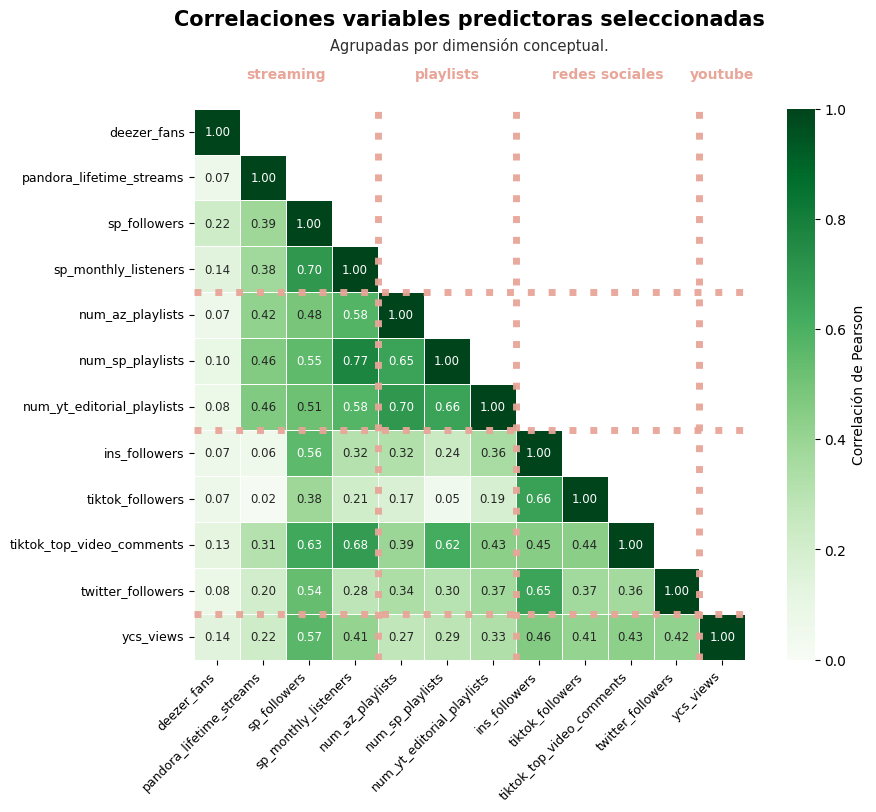

In [15]:
# ============================================================
# Heatmap de correlaciones internas agrupado por dimensión
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ------------------------------------------------------------
# Función auxiliar de dimensión
# ------------------------------------------------------------

def asignar_dimension(variable):
    if variable in streaming_cols:
        return "streaming"
    elif variable in playlist_cols:
        return "playlists"
    elif variable in social_cols:
        return "redes sociales"
    elif variable in youtube_cols:
        return "youtube"
    else:
        return "otra"

# ------------------------------------------------------------
# Orden conceptual de dimensiones
# ------------------------------------------------------------

orden_dimensiones = [
    "streaming",
    "playlists",
    "redes sociales",
    "youtube"
]

# ------------------------------------------------------------
# Tabla de orden del subset preliminar
# ------------------------------------------------------------

orden_variables_heatmap = pd.DataFrame({
    "variable": variables_regresion_preliminar
})

orden_variables_heatmap["dimension"] = (
    orden_variables_heatmap["variable"]
    .apply(asignar_dimension)
)

orden_variables_heatmap["orden_dimension"] = (
    orden_variables_heatmap["dimension"]
    .map({dim: i for i, dim in enumerate(orden_dimensiones)})
)

orden_variables_heatmap = (
    orden_variables_heatmap
    .sort_values(["orden_dimension", "variable"])
    .reset_index(drop=True)
)

variables_ordenadas = orden_variables_heatmap["variable"].tolist()

# ------------------------------------------------------------
# Preparación de variables transformadas
# ------------------------------------------------------------

df_heatmap_dim = df.copy()

vars_log_heatmap = [
    col for col in variables_ordenadas
    if col != "sp_popularity"
]

for col in vars_log_heatmap:
    df_heatmap_dim[f"log1p_{col}"] = np.log1p(df_heatmap_dim[col].astype(float))

vars_heatmap = [
    f"log1p_{col}" if col != "sp_popularity" else col
    for col in variables_ordenadas
]

labels_heatmap = [
    col.replace("log1p_", "")
    for col in vars_heatmap
]

# ------------------------------------------------------------
# Matriz de correlación
# ------------------------------------------------------------

corr_heatmap_dim = df_heatmap_dim[vars_heatmap].corr(method="pearson")

# ------------------------------------------------------------
# Máscara para mostrar solo triángulo inferior
# ------------------------------------------------------------

mask = np.triu(
    np.ones_like(corr_heatmap_dim, dtype=bool),
    k=1
)

# ------------------------------------------------------------
# Posiciones de cortes entre dimensiones
# ------------------------------------------------------------

conteo_dimensiones = (
    orden_variables_heatmap
    .groupby("dimension", sort=False)
    .size()
)

cortes = np.cumsum(conteo_dimensiones.values)[:-1]

# ------------------------------------------------------------
# Gráfico
# ------------------------------------------------------------

fig, ax = plt.subplots(figsize=(12, 9.5))

sns.heatmap(
    corr_heatmap_dim,
    mask=mask,
    cmap="Greens",
    vmin=0,
    vmax=1,
    square=True,
    linewidths=0.6,
    linecolor="white",
    annot=True,
    fmt=".2f",
    annot_kws={"fontsize": 8.5},
    cbar_kws={"label": "Correlación de Pearson"},
    xticklabels=labels_heatmap,
    yticklabels=labels_heatmap,
    ax=ax
)

# ------------------------------------------------------------
# Líneas separadoras entre dimensiones
# ------------------------------------------------------------

color_separador = "#E8A598"

for corte in cortes:
    ax.axhline(
        corte,
        color=color_separador,
        linewidth=5,
        linestyle=(0, (1, 2)),
        alpha=0.95
    )
    
    ax.axvline(
        corte,
        color=color_separador,
        linewidth=5,
        linestyle=(0, (1, 2)),
        alpha=0.95
    )

# ------------------------------------------------------------
# Título y subtítulo
# ------------------------------------------------------------

# ax.set_title(
#     "Correlaciones variables seleccionadas",
#     fontsize=15,
#     fontweight="bold",
#     pad=24,
#     loc="center"
# )

# ax.text(
#     0.5,
#     1.025,
#     "Agrupadas por dimensión conceptual",
#     transform=ax.transAxes,
#     ha="center",
#     va="bottom",
#     fontsize=10.5,
#     color="#2F2F2F"
# )

ax.set_title(
    "Correlaciones variables predictoras seleccionadas",
    fontsize=15,
    fontweight="bold",
    pad=60,
    loc="center"
)

ax.text(
    0.5,
    1.1,
    "Agrupadas por dimensión conceptual.",
    transform=ax.transAxes,
    ha="center",
    va="bottom",
    fontsize=10.5,
    color="#2F2F2F"
)


# ------------------------------------------------------------
# Etiquetas de dimensión sobre el eje superior
# ------------------------------------------------------------

inicio = 0

for dimension, cantidad in conteo_dimensiones.items():
    centro = inicio + cantidad / 2
    
    ax.text(
        centro,
        -0.75,
        dimension,
        ha="center",
        va="center",
        fontsize=10,
        fontweight="bold",
        color= color_separador
    )
    
    inicio += cantidad

# ------------------------------------------------------------
# Estética general
# ------------------------------------------------------------

ax.tick_params(axis="x", rotation=45, labelsize=9)
ax.tick_params(axis="y", rotation=0, labelsize=9)

for label in ax.get_xticklabels():
    label.set_horizontalalignment("right")

plt.subplots_adjust(
    top=0.82,
    bottom=0.24,
    left=0.22,
    right=0.92
)

plt.savefig(
    "grafico_heatmap_correlaciones_subset.png",
    dpi=300,
    bbox_inches="tight",
    facecolor="white"
)

plt.show()



# selección avanzada

Criterios finales de selección
asociación con la target
estabilidad entre Pearson/Spearman
reducción de redundancia
interpretabilidad
completitud
representación de dimensiones digitales

DESCARTADOS:
num_az_playlists (descarty y priorizo num_yt_editorial_playlists)
sp_followers (descarto y priorizo con sp_monthly_listeners)
tiktok_followers (descarto por muchos null)

CONSERVO:
num_sp_playlists (alta con sp_monthly_listeners)
sp_monthly_listeners (alta con num_sp_playlists y sp_followers)
num_yt_editorial_playlists (alta con num_az_playlists)
tiktok_top_video_comments
pandora_lifetime_streams
ycs_views

+ 3 baja multicolinealidad
'deezer_fans',
'ins_followers',
'twitter_followers'

CATEGORICAS
"country_short",
"genre_short",
"pronoun_short",
"band",
"major_record_label"


# PREPARO REGRESION

In [16]:
# ============================================================
# Consolidación final para avanzar a regresión lineal
# ============================================================

import numpy as np
import pandas as pd

# ------------------------------------------------------------
# Target y set final de predictoras
# ------------------------------------------------------------

target = "n_shows_24_25"

variables_regresion_final = [
    "num_yt_editorial_playlists",
    "num_sp_playlists",
    "ins_followers",
    "twitter_followers",
    "tiktok_top_video_comments",
    "sp_monthly_listeners",
    "pandora_lifetime_streams",
    "deezer_fans",
    "ycs_views"
]

categoricas_regresion = [
    "country_short",
    "genre_short",
    "pronoun_short",
    "band",
    "major_record_label"
]

# ------------------------------------------------------------
# Control de leakage
# ------------------------------------------------------------

variables_live_predictoras = [
    col for col in variables_regresion_final
    if col in live_cols
]

if len(variables_live_predictoras) > 0:
    raise ValueError(
        f"Hay variables live dentro de las predictoras: {variables_live_predictoras}"
    )

# ------------------------------------------------------------
# Control de existencia de columnas
# ------------------------------------------------------------

columnas_necesarias = (
    [target, "chartmetric_id"]
    + variables_regresion_final
    + categoricas_regresion
)

columnas_faltantes = [
    col for col in columnas_necesarias
    if col not in df.columns
]

if len(columnas_faltantes) > 0:
    raise ValueError(
        f"Columnas faltantes en df: {columnas_faltantes}"
    )

# ------------------------------------------------------------
# Tabla final de documentación de variables
# ------------------------------------------------------------

tabla_variables_regresion = (
    control_regresion_preliminar
    .copy()
    .loc[
        control_regresion_preliminar["variable"].isin(variables_regresion_final)
    ]
    .sort_values(["dimension", "pearson_target"], ascending=[True, False])
    .reset_index(drop=True)
)

tabla_variables_regresion["decision_modelado"] = "incluida_regresion_lineal_preliminar"

display(tabla_variables_regresion)


,variable,dimension,pearson_target,spearman_target,pct_null,n_pares_altos,max_corr_con_otra_var,corr_media_con_otras_vars,aparece_en_pares_altos,decision_consolidada,max_corr_dentro_subset,corr_media_dentro_subset,n_pares_subset_070,n_pares_subset_085,decision_modelado
0,num_yt_editorial_playlists,playlists,0.217,0.222,1.91,6,0.796,0.722,True,conservar_preliminar,0.700,0.425,1,0,incluida_regresion_lineal_preliminar
1,num_sp_playlists,playlists,0.201,0.189,0.00,8,0.898,0.790,True,conservar_preliminar,0.774,0.426,1,0,incluida_regresion_lineal_preliminar
2,ins_followers,redes_sociales,0.176,0.129,6.78,0,NaN,NaN,False,sin_decision_por_no_redundante,0.661,0.376,0,0,incluida_regresion_lineal_preliminar
3,twitter_followers,redes_sociales,0.164,0.129,19.23,0,NaN,NaN,False,sin_decision_por_no_redundante,0.650,0.356,0,0,incluida_regresion_lineal_preliminar
4,tiktok_top_video_comments,redes_sociales,0.137,0.113,0.16,2,0.971,0.947,True,conservar_preliminar,0.681,0.444,0,0,incluida_regresion_lineal_preliminar
5,sp_monthly_listeners,streaming,0.190,0.171,0.12,6,0.928,0.787,True,conservar_preliminar,0.774,0.459,2,0,incluida_regresion_lineal_preliminar
6,pandora_lifetime_streams,streaming,0.187,0.208,1.95,1,0.937,0.937,True,conservar_preliminar,0.462,0.271,0,0,incluida_regresion_lineal_preliminar
7,deezer_fans,streaming,0.079,0.087,1.22,0,NaN,NaN,False,sin_decision_por_no_redundante,0.222,0.106,0,0,incluida_regresion_lineal_preliminar
8,ycs_views,youtube,0.152,0.134,4.95,1,0.880,0.880,True,conservar_preliminar,0.565,0.359,0,0,incluida_regresion_lineal_preliminar


# transformación log

In [17]:
# ------------------------------------------------------------
# Dataset de modelado
# ------------------------------------------------------------

df_modelo_lineal = df[
    ["chartmetric_id", target]
    + variables_regresion_final
    + categoricas_regresion
].copy()

df_modelo_lineal["log1p_n_shows_24_25"] = np.log1p(
    df_modelo_lineal[target].astype(float)
)

for col in variables_regresion_final:
    df_modelo_lineal[f"log1p_{col}"] = np.log1p(
        df_modelo_lineal[col].astype(float)
    )

variables_regresion_final_log = [
    f"log1p_{col}"
    for col in variables_regresion_final
]

columnas_modelo = (
    ["chartmetric_id", "log1p_n_shows_24_25"]
    + variables_regresion_final_log
    + categoricas_regresion
)

df_modelo_lineal = df_modelo_lineal[columnas_modelo].copy()



# nulos e imput para lineal

In [18]:
# ------------------------------------------------------------
# Diagnóstico de nulos antes de ajustar regresión lineal
# ------------------------------------------------------------

resumen_nulos_modelo = (
    df_modelo_lineal
    .isna()
    .sum()
    .reset_index()
)

resumen_nulos_modelo.columns = ["variable", "n_null"]

resumen_nulos_modelo["pct_null"] = (
    resumen_nulos_modelo["n_null"] / len(df_modelo_lineal) * 100
).round(2)

resumen_nulos_modelo = (
    resumen_nulos_modelo
    .sort_values("pct_null", ascending=False)
    .reset_index(drop=True)
)

display(resumen_nulos_modelo)

# ------------------------------------------------------------
# Registros completos por bloque
# ------------------------------------------------------------

columnas_numericas_modelo = [
    "log1p_n_shows_24_25"
] + variables_regresion_final_log

columnas_categoricas_modelo = categoricas_regresion.copy()

n_total = df_modelo_lineal.shape[0]

n_completo_numericas = (
    df_modelo_lineal[columnas_numericas_modelo]
    .dropna()
    .shape[0]
)

n_completo_categoricas = (
    df_modelo_lineal[columnas_categoricas_modelo]
    .dropna()
    .shape[0]
)

n_completo_total = df_modelo_lineal.dropna().shape[0]

print("Artistas iniciales:", n_total)

print(
    "Artistas completos en variables numéricas:",
    n_completo_numericas,
    "| porcentaje:",
    round(n_completo_numericas / n_total * 100, 2)
)

print(
    "Artistas completos en variables categóricas:",
    n_completo_categoricas,
    "| porcentaje:",
    round(n_completo_categoricas / n_total * 100, 2)
)

print(
    "Artistas completos en todo el set de modelado:",
    n_completo_total,
    "| porcentaje:",
    round(n_completo_total / n_total * 100, 2)
)

print(
    "Artistas que se perderían si se aplica dropna total:",
    n_total - n_completo_total
)

,variable,n_null,pct_null
0,log1p_twitter_followers,945,19.23
1,log1p_ins_followers,333,6.78
2,major_record_label,309,6.29
3,log1p_ycs_views,243,4.95
4,log1p_pandora_lifetime_streams,96,1.95
5,log1p_num_yt_editorial_playlists,94,1.91
6,log1p_deezer_fans,60,1.22
7,log1p_tiktok_top_video_comments,8,0.16
8,log1p_sp_monthly_listeners,6,0.12
9,country_short,4,0.08


Artistas iniciales: 4913
Artistas completos en variables numéricas: 3684 | porcentaje: 74.98
Artistas completos en variables categóricas: 4600 | porcentaje: 93.63
Artistas completos en todo el set de modelado: 3487 | porcentaje: 70.97
Artistas que se perderían si se aplica dropna total: 1426


In [19]:
# ------------------------------------------------------------
# Tratamiento de nulos para regresión lineal
# ------------------------------------------------------------

df_modelo_lineal_imp = df_modelo_lineal.copy()

# ------------------------------------------------------------
# Variables imputadas con valor sustantivo
# ------------------------------------------------------------

df_modelo_lineal_imp["log1p_twitter_followers_imp"] = (
    df_modelo_lineal_imp["log1p_twitter_followers"]
    .fillna(0)
)

df_modelo_lineal_imp["log1p_ins_followers_imp"] = (
    df_modelo_lineal_imp["log1p_ins_followers"]
    .fillna(0)
)

df_modelo_lineal_imp["major_record_label_imp"] = (
    df_modelo_lineal_imp["major_record_label"]
    .fillna(False)
)

# ------------------------------------------------------------
# Variables copiadas con sufijo _imp para conservar trazabilidad
# ------------------------------------------------------------

df_modelo_lineal_imp["log1p_ycs_views_imp"] = df_modelo_lineal_imp["log1p_ycs_views"]
df_modelo_lineal_imp["log1p_pandora_lifetime_streams_imp"] = df_modelo_lineal_imp["log1p_pandora_lifetime_streams"]
df_modelo_lineal_imp["log1p_num_yt_editorial_playlists_imp"] = df_modelo_lineal_imp["log1p_num_yt_editorial_playlists"]
df_modelo_lineal_imp["log1p_deezer_fans_imp"] = df_modelo_lineal_imp["log1p_deezer_fans"]
df_modelo_lineal_imp["log1p_tiktok_top_video_comments_imp"] = df_modelo_lineal_imp["log1p_tiktok_top_video_comments"]
df_modelo_lineal_imp["log1p_sp_monthly_listeners_imp"] = df_modelo_lineal_imp["log1p_sp_monthly_listeners"]
df_modelo_lineal_imp["country_short_imp"] = df_modelo_lineal_imp["country_short"]

# ------------------------------------------------------------
# Drop de registros con nulos remanentes
# ------------------------------------------------------------

variables_dropna_imp = [
    "log1p_ycs_views_imp",
    "log1p_pandora_lifetime_streams_imp",
    "log1p_num_yt_editorial_playlists_imp",
    "log1p_deezer_fans_imp",
    "log1p_tiktok_top_video_comments_imp",
    "log1p_sp_monthly_listeners_imp",
    "country_short_imp"
]

n_antes = df_modelo_lineal_imp.shape[0]

df_modelo_lineal_imp = (
    df_modelo_lineal_imp
    .dropna(subset=variables_dropna_imp)
    .copy()
)

n_despues = df_modelo_lineal_imp.shape[0]

print("Artistas antes del tratamiento:", n_antes)
print("Artistas después del tratamiento:", n_despues)
print("Artistas eliminados por nulos remanentes:", n_antes - n_despues)
print("Porcentaje conservado:", round(n_despues / n_antes * 100, 2))

# ------------------------------------------------------------
# Listas finales para modelado
# ------------------------------------------------------------

features_numericas_imp = [
    "log1p_num_yt_editorial_playlists_imp",
    "log1p_num_sp_playlists",
    "log1p_ins_followers_imp",
    "log1p_twitter_followers_imp",
    "log1p_tiktok_top_video_comments_imp",
    "log1p_sp_monthly_listeners_imp",
    "log1p_pandora_lifetime_streams_imp",
    "log1p_deezer_fans_imp",
    "log1p_ycs_views_imp"
]

features_categoricas_imp = [
    "country_short_imp",
    "genre_short",
    "pronoun_short",
    "band",
    "major_record_label_imp"
]

features_modelo_imp = features_numericas_imp + features_categoricas_imp

# ------------------------------------------------------------
# Control final de nulos
# ------------------------------------------------------------

resumen_nulos_imp = (
    df_modelo_lineal_imp[
        ["log1p_n_shows_24_25"] + features_modelo_imp
    ]
    .isna()
    .sum()
    .reset_index()
)

resumen_nulos_imp.columns = ["variable", "n_null"]

resumen_nulos_imp["pct_null"] = (
    resumen_nulos_imp["n_null"] / len(df_modelo_lineal_imp) * 100
).round(2)

display(resumen_nulos_imp)

Artistas antes del tratamiento: 4913
Artistas después del tratamiento: 4505
Artistas eliminados por nulos remanentes: 408
Porcentaje conservado: 91.7


,variable,n_null,pct_null
0,log1p_n_shows_24_25,0,0.0
1,log1p_num_yt_editorial_playlists_imp,0,0.0
2,log1p_num_sp_playlists,0,0.0
3,log1p_ins_followers_imp,0,0.0
4,log1p_twitter_followers_imp,0,0.0
5,log1p_tiktok_top_video_comments_imp,0,0.0
6,log1p_sp_monthly_listeners_imp,0,0.0
7,log1p_pandora_lifetime_streams_imp,0,0.0
8,log1p_deezer_fans_imp,0,0.0
9,log1p_ycs_views_imp,0,0.0


# estratificación, participon, entrenamiento

In [20]:
import sys

# !{sys.executable} -m pip install scikit-learn

In [21]:
# ============================================================
# Partición estratificada y esquema de validación robusta
# ============================================================

import numpy as np
import pandas as pd
import sklearn
from sklearn.model_selection import train_test_split, RepeatedStratifiedKFold

# ------------------------------------------------------------
# Reconstrucción de target en escala original para estratificación
# ------------------------------------------------------------

df_modelo_lineal_imp["n_shows_24_25_original"] = np.expm1(
    df_modelo_lineal_imp["log1p_n_shows_24_25"]
)

# ------------------------------------------------------------
# Estratos de actividad en vivo
# ------------------------------------------------------------

df_modelo_lineal_imp["estrato_target"] = pd.cut(
    df_modelo_lineal_imp["n_shows_24_25_original"],
    bins=[-1, 0, 5, 20, 60, np.inf],
    labels=[
        "0_shows",
        "1_5_shows",
        "6_20_shows",
        "21_60_shows",
        "61_mas_shows"
    ]
)

# ------------------------------------------------------------
# Control de distribución de estratos
# ------------------------------------------------------------

distribucion_estratos = (
    df_modelo_lineal_imp["estrato_target"]
    .value_counts(dropna=False)
    .rename_axis("estrato_target")
    .reset_index(name="n")
)

distribucion_estratos["pct"] = (
    distribucion_estratos["n"] / len(df_modelo_lineal_imp) * 100
).round(2)

display(distribucion_estratos)

# ------------------------------------------------------------
# Features disponibles para modelos lineales
# ------------------------------------------------------------

features_playlists = [
    "log1p_num_yt_editorial_playlists_imp",
    "log1p_num_sp_playlists"
]

features_streaming = [
    "log1p_sp_monthly_listeners_imp",
    "log1p_pandora_lifetime_streams_imp",
    "log1p_deezer_fans_imp"
]

features_redes_sociales = [
    "log1p_ins_followers_imp",
    "log1p_twitter_followers_imp",
    "log1p_tiktok_top_video_comments_imp"
]

features_youtube = [
    "log1p_ycs_views_imp"
]

features_categoricas = [
    "country_short_imp",
    "genre_short",
    "pronoun_short",
    "band",
    "major_record_label_imp"
]

features_numericas_completo = (
    features_playlists
    + features_streaming
    + features_redes_sociales
    + features_youtube
)

features_modelo_completo = (
    features_numericas_completo
    + features_categoricas
)

# ------------------------------------------------------------
# Matriz general y target
# ------------------------------------------------------------

X_all = df_modelo_lineal_imp[features_modelo_completo].copy()
y_all = df_modelo_lineal_imp["log1p_n_shows_24_25"].copy()
ids_all = df_modelo_lineal_imp["chartmetric_id"].copy()
estratos_all = df_modelo_lineal_imp["estrato_target"].copy()

# ------------------------------------------------------------
# Split holdout estratificado
# ------------------------------------------------------------

X_train_all, X_test_all, y_train, y_test, ids_train, ids_test, estratos_train, estratos_test = train_test_split(
    X_all,
    y_all,
    ids_all,
    estratos_all,
    test_size=0.20,
    random_state=42,
    stratify=estratos_all
)

# ------------------------------------------------------------
# Control de distribución train/test
# ------------------------------------------------------------

comparacion_estratos = pd.DataFrame({
    "train_n": estratos_train.value_counts().sort_index(),
    "test_n": estratos_test.value_counts().sort_index()
})

comparacion_estratos["train_pct"] = (
    comparacion_estratos["train_n"] / len(estratos_train) * 100
).round(2)

comparacion_estratos["test_pct"] = (
    comparacion_estratos["test_n"] / len(estratos_test) * 100
).round(2)

display(comparacion_estratos)

print("Train:", X_train_all.shape)
print("Test:", X_test_all.shape)

# ------------------------------------------------------------
# Esquema de validación cruzada dentro de train
# ------------------------------------------------------------

cv_robusta = RepeatedStratifiedKFold(
    n_splits=5,
    n_repeats=3,
    random_state=42
)

,estrato_target,n,pct
0,21_60_shows,1309,29.06
1,6_20_shows,950,21.09
2,1_5_shows,939,20.84
3,0_shows,680,15.09
4,61_mas_shows,627,13.92


,train_n,test_n,train_pct,test_pct
estrato_target,,,,
0_shows,544,136,15.09,15.09
1_5_shows,751,188,20.84,20.87
6_20_shows,760,190,21.09,21.09
21_60_shows,1047,262,29.05,29.08
61_mas_shows,502,125,13.93,13.87


Train: (3604, 14)
Test: (901, 14)


# Regresiones lineales

## sklearn

In [22]:
# ============================================================
# Modelos lineales por dimensión, baseline y modelo completo
# ============================================================

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# ------------------------------------------------------------
# Función auxiliar para OneHotEncoder compatible
# ------------------------------------------------------------

def crear_onehot_encoder():
    try:
        return OneHotEncoder(
            drop="first",
            handle_unknown="ignore",
            sparse_output=False
        )
    except TypeError:
        return OneHotEncoder(
            drop="first",
            handle_unknown="ignore",
            sparse=False
        )

# ------------------------------------------------------------
# Definición de modelos a comparar
# ------------------------------------------------------------

modelos_lineales = {
    "solo_controles": {
        "numericas": [],
        "categoricas": features_categoricas
    },
    "playlists_sin_controles": {
        "numericas": features_playlists,
        "categoricas": []
    },
    "streaming_sin_controles": {
        "numericas": features_streaming,
        "categoricas": []
    },
    "redes_sociales_sin_controles": {
        "numericas": features_redes_sociales,
        "categoricas": []
    },
    "youtube_sin_controles": {
        "numericas": features_youtube,
        "categoricas": []
    },
    "playlists_con_controles": {
        "numericas": features_playlists,
        "categoricas": features_categoricas
    },
    "streaming_con_controles": {
        "numericas": features_streaming,
        "categoricas": features_categoricas
    },
    "redes_sociales_con_controles": {
        "numericas": features_redes_sociales,
        "categoricas": features_categoricas
    },
    "youtube_con_controles": {
        "numericas": features_youtube,
        "categoricas": features_categoricas
    },
    "completo_sin_controles": {
        "numericas": features_numericas_completo,
        "categoricas": []
    },
    "completo_con_controles": {
        "numericas": features_numericas_completo,
        "categoricas": features_categoricas
    }
}

# ------------------------------------------------------------
# Función para construir pipeline
# ------------------------------------------------------------

def construir_pipeline_lineal(features_numericas, features_categoricas):
    
    transformers = []
    
    if len(features_numericas) > 0:
        transformers.append(
            (
                "num",
                StandardScaler(),
                features_numericas
            )
        )
    
    if len(features_categoricas) > 0:
        transformers.append(
            (
                "cat",
                crear_onehot_encoder(),
                features_categoricas
            )
        )
    
    preprocesamiento = ColumnTransformer(
        transformers=transformers,
        remainder="drop"
    )
    
    pipeline = Pipeline(
        steps=[
            ("preprocesamiento", preprocesamiento),
            ("regresion", LinearRegression())
        ]
    )
    
    return pipeline

# ------------------------------------------------------------
# Validación cruzada manual estratificada dentro de train
# ------------------------------------------------------------

resultados_modelos = []
modelos_ajustados = {}

for nombre_modelo, config in modelos_lineales.items():
    
    features_numericas = config["numericas"]
    features_categoricas_modelo = config["categoricas"]
    features_modelo = features_numericas + features_categoricas_modelo
    
    X_train = X_train_all[features_modelo].copy()
    X_test = X_test_all[features_modelo].copy()
    
    metricas_cv = []
    
    for fold_id, (idx_train_cv, idx_val_cv) in enumerate(
        cv_robusta.split(X_train, estratos_train),
        start=1
    ):
        
        X_train_cv = X_train.iloc[idx_train_cv].copy()
        X_val_cv = X_train.iloc[idx_val_cv].copy()
        
        y_train_cv = y_train.iloc[idx_train_cv].copy()
        y_val_cv = y_train.iloc[idx_val_cv].copy()
        
        pipeline = construir_pipeline_lineal(
            features_numericas=features_numericas,
            features_categoricas=features_categoricas_modelo
        )
        
        pipeline.fit(X_train_cv, y_train_cv)
        
        y_pred_val_cv = pipeline.predict(X_val_cv)
        
        rmse_cv = mean_squared_error(y_val_cv, y_pred_val_cv) ** 0.5
        mae_cv = mean_absolute_error(y_val_cv, y_pred_val_cv)
        r2_cv = r2_score(y_val_cv, y_pred_val_cv)
        
        metricas_cv.append({
            "fold": fold_id,
            "rmse": rmse_cv,
            "mae": mae_cv,
            "r2": r2_cv
        })
    
    metricas_cv = pd.DataFrame(metricas_cv)
    
    # --------------------------------------------------------
    # Ajuste final en todo train y evaluación en test
    # --------------------------------------------------------
    
    pipeline_final = construir_pipeline_lineal(
        features_numericas=features_numericas,
        features_categoricas=features_categoricas_modelo
    )
    
    pipeline_final.fit(X_train, y_train)
    
    y_pred_train = pipeline_final.predict(X_train)
    y_pred_test = pipeline_final.predict(X_test)
    
    modelos_ajustados[nombre_modelo] = pipeline_final
    
    resultados_modelos.append({
        "modelo": nombre_modelo,
        "n_features_numericas": len(features_numericas),
        "n_features_categoricas_originales": len(features_categoricas_modelo),
        "cv_rmse_media": metricas_cv["rmse"].mean(),
        "cv_rmse_sd": metricas_cv["rmse"].std(),
        "cv_mae_media": metricas_cv["mae"].mean(),
        "cv_mae_sd": metricas_cv["mae"].std(),
        "cv_r2_media": metricas_cv["r2"].mean(),
        "cv_r2_sd": metricas_cv["r2"].std(),
        "train_rmse": mean_squared_error(y_train, y_pred_train) ** 0.5,
        "test_rmse": mean_squared_error(y_test, y_pred_test) ** 0.5,
        "train_mae": mean_absolute_error(y_train, y_pred_train),
        "test_mae": mean_absolute_error(y_test, y_pred_test),
        "train_r2": r2_score(y_train, y_pred_train),
        "test_r2": r2_score(y_test, y_pred_test),
        "brecha_r2_train_test": (
            r2_score(y_train, y_pred_train)
            - r2_score(y_test, y_pred_test)
        )
    })

resultados_modelos = pd.DataFrame(resultados_modelos)

# ------------------------------------------------------------
# Tabla comparativa de modelos
# ------------------------------------------------------------

resultados_modelos = (
    resultados_modelos
    .sort_values(
        ["test_r2", "test_rmse"],
        ascending=[False, True]
    )
    .reset_index(drop=True)
)

display(resultados_modelos)

,modelo,n_features_numericas,n_features_categoricas_originales,cv_rmse_media,cv_rmse_sd,cv_mae_media,cv_mae_sd,cv_r2_media,cv_r2_sd,train_rmse,test_rmse,train_mae,test_mae,train_r2,test_r2,brecha_r2_train_test
0,redes_sociales_con_controles,3,5,1.377299,0.017676,1.153934,0.018363,0.174100,0.020090,1.367446,1.399117,1.145930,1.165384,0.186020,0.129088,0.056931
1,completo_con_controles,9,5,1.372363,0.017982,1.146700,0.018964,0.179997,0.020675,1.360901,1.401351,1.137295,1.162865,0.193794,0.126305,0.067489
2,completo_sin_controles,9,0,1.428991,0.014024,1.217058,0.013790,0.111021,0.014422,1.426078,1.441566,1.214613,1.224128,0.114721,0.075439,0.039282
3,redes_sociales_sin_controles,3,0,1.458296,0.013676,1.256837,0.013963,0.074197,0.013745,1.457151,1.442009,1.255824,1.237249,0.075722,0.074871,0.000851
4,youtube_con_controles,1,5,1.424827,0.017596,1.208552,0.014057,0.116106,0.021433,1.415782,1.449427,1.201046,1.226961,0.127459,0.065329,0.062130
5,playlists_con_controles,2,5,1.427629,0.017316,1.210439,0.014240,0.112614,0.021905,1.417889,1.453904,1.202145,1.228388,0.124860,0.059546,0.065314
6,solo_controles,0,5,1.444090,0.013233,1.230886,0.012576,0.092090,0.016866,1.435238,1.461312,1.223337,1.243334,0.103313,0.049937,0.053375
7,streaming_con_controles,3,5,1.429906,0.016227,1.213997,0.012951,0.109797,0.020573,1.420195,1.464462,1.205829,1.241276,0.122011,0.045838,0.076173
8,playlists_sin_controles,2,0,1.485047,0.010127,1.284180,0.011310,0.039910,0.012038,1.484376,1.478519,1.283575,1.273482,0.040862,0.027432,0.013430
9,youtube_sin_controles,1,0,1.498391,0.009269,1.301621,0.012238,0.022624,0.006343,1.498212,1.488543,1.301453,1.293233,0.022898,0.014200,0.008698


In [23]:
# ============================================================
# Tabla sintética para interpretación de modelos
# ============================================================

tabla_comparacion_modelos = resultados_modelos[
    [
        "modelo",
        "n_features_numericas",
        "n_features_categoricas_originales",
        "cv_r2_media",
        "cv_r2_sd",
        "test_r2",
        "cv_rmse_media",
        "cv_rmse_sd",
        "test_rmse",
        "test_mae",
        "brecha_r2_train_test"
    ]
].copy()

columnas_redondear = [
    "cv_r2_media",
    "cv_r2_sd",
    "test_r2",
    "cv_rmse_media",
    "cv_rmse_sd",
    "test_rmse",
    "test_mae",
    "brecha_r2_train_test"
]

tabla_comparacion_modelos[columnas_redondear] = (
    tabla_comparacion_modelos[columnas_redondear]
    .round(3)
)

display(tabla_comparacion_modelos)

,modelo,n_features_numericas,n_features_categoricas_originales,cv_r2_media,cv_r2_sd,test_r2,cv_rmse_media,cv_rmse_sd,test_rmse,test_mae,brecha_r2_train_test
0,redes_sociales_con_controles,3,5,0.174,0.020,0.129,1.377,0.018,1.399,1.165,0.057
1,completo_con_controles,9,5,0.180,0.021,0.126,1.372,0.018,1.401,1.163,0.067
2,completo_sin_controles,9,0,0.111,0.014,0.075,1.429,0.014,1.442,1.224,0.039
3,redes_sociales_sin_controles,3,0,0.074,0.014,0.075,1.458,0.014,1.442,1.237,0.001
4,youtube_con_controles,1,5,0.116,0.021,0.065,1.425,0.018,1.449,1.227,0.062
5,playlists_con_controles,2,5,0.113,0.022,0.060,1.428,0.017,1.454,1.228,0.065
6,solo_controles,0,5,0.092,0.017,0.050,1.444,0.013,1.461,1.243,0.053
7,streaming_con_controles,3,5,0.110,0.021,0.046,1.430,0.016,1.464,1.241,0.076
8,playlists_sin_controles,2,0,0.040,0.012,0.027,1.485,0.010,1.479,1.273,0.013
9,youtube_sin_controles,1,0,0.023,0.006,0.014,1.498,0.009,1.489,1.293,0.009


In [24]:
# ============================================================
# Comparación contra baseline solo controles
# ============================================================

baseline = (
    resultados_modelos
    .loc[resultados_modelos["modelo"] == "solo_controles"]
    .iloc[0]
)

comparacion_vs_baseline = resultados_modelos.copy()

comparacion_vs_baseline["delta_test_r2_vs_controles"] = (
    comparacion_vs_baseline["test_r2"] - baseline["test_r2"]
)

comparacion_vs_baseline["delta_test_rmse_vs_controles"] = (
    comparacion_vs_baseline["test_rmse"] - baseline["test_rmse"]
)

comparacion_vs_baseline["delta_test_mae_vs_controles"] = (
    comparacion_vs_baseline["test_mae"] - baseline["test_mae"]
)

comparacion_vs_baseline = comparacion_vs_baseline[
    [
        "modelo",
        "test_r2",
        "delta_test_r2_vs_controles",
        "test_rmse",
        "delta_test_rmse_vs_controles",
        "test_mae",
        "delta_test_mae_vs_controles",
        "brecha_r2_train_test"
    ]
].copy()

comparacion_vs_baseline = (
    comparacion_vs_baseline
    .sort_values("delta_test_r2_vs_controles", ascending=False)
    .reset_index(drop=True)
)

columnas_redondear = [
    "test_r2",
    "delta_test_r2_vs_controles",
    "test_rmse",
    "delta_test_rmse_vs_controles",
    "test_mae",
    "delta_test_mae_vs_controles",
    "brecha_r2_train_test"
]

comparacion_vs_baseline[columnas_redondear] = (
    comparacion_vs_baseline[columnas_redondear]
    .round(3)
)

display(comparacion_vs_baseline)

,modelo,test_r2,delta_test_r2_vs_controles,test_rmse,delta_test_rmse_vs_controles,test_mae,delta_test_mae_vs_controles,brecha_r2_train_test
0,redes_sociales_con_controles,0.129,0.079,1.399,-0.062,1.165,-0.078,0.057
1,completo_con_controles,0.126,0.076,1.401,-0.060,1.163,-0.080,0.067
2,completo_sin_controles,0.075,0.026,1.442,-0.020,1.224,-0.019,0.039
3,redes_sociales_sin_controles,0.075,0.025,1.442,-0.019,1.237,-0.006,0.001
4,youtube_con_controles,0.065,0.015,1.449,-0.012,1.227,-0.016,0.062
5,playlists_con_controles,0.060,0.010,1.454,-0.007,1.228,-0.015,0.065
6,solo_controles,0.050,0.000,1.461,0.000,1.243,0.000,0.053
7,streaming_con_controles,0.046,-0.004,1.464,0.003,1.241,-0.002,0.076
8,playlists_sin_controles,0.027,-0.023,1.479,0.017,1.273,0.030,0.013
9,youtube_sin_controles,0.014,-0.036,1.489,0.027,1.293,0.050,0.009


## OLS statsmodels

In [25]:
#!{sys.executable} -m pip install statsmodels

In [26]:
# ============================================================
# Statsmodels OLS para todos los modelos lineales
# ============================================================

import statsmodels.api as sm
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

modelos_statsmodels = {}
resultados_statsmodels = []

def preparar_matriz_ols(X_base, features_numericas, features_categoricas):
    
    X_modelo = X_base[features_numericas + features_categoricas].copy()
    
    if len(features_categoricas) > 0:
        X_modelo = pd.get_dummies(
            X_modelo,
            columns=features_categoricas,
            drop_first=True,
            dtype=float
        )
    
    for col in X_modelo.columns:
        X_modelo[col] = X_modelo[col].astype(float)
    
    X_modelo = sm.add_constant(X_modelo, has_constant="add")
    
    return X_modelo

for nombre_modelo, config in modelos_lineales.items():
    
    features_numericas = config["numericas"]
    features_categoricas_modelo = config["categoricas"]
    
    X_train_sm = preparar_matriz_ols(
        X_train_all,
        features_numericas,
        features_categoricas_modelo
    )
    
    X_test_sm = preparar_matriz_ols(
        X_test_all,
        features_numericas,
        features_categoricas_modelo
    )
    
    X_test_sm = X_test_sm.reindex(columns=X_train_sm.columns, fill_value=0)
    
    modelo_sm = sm.OLS(y_train.astype(float), X_train_sm).fit()
    
    y_pred_train_sm = modelo_sm.predict(X_train_sm)
    y_pred_test_sm = modelo_sm.predict(X_test_sm)
    
    modelos_statsmodels[nombre_modelo] = modelo_sm
    
    resultados_statsmodels.append({
        "modelo": nombre_modelo,
        "n_parametros": int(modelo_sm.df_model + 1),
        "aic": modelo_sm.aic,
        "bic": modelo_sm.bic,
        "adj_r2_train": modelo_sm.rsquared_adj,
        "r2_train": r2_score(y_train, y_pred_train_sm),
        "r2_test": r2_score(y_test, y_pred_test_sm),
        "rmse_train": mean_squared_error(y_train, y_pred_train_sm) ** 0.5,
        "rmse_test": mean_squared_error(y_test, y_pred_test_sm) ** 0.5,
        "mae_train": mean_absolute_error(y_train, y_pred_train_sm),
        "mae_test": mean_absolute_error(y_test, y_pred_test_sm),
        "brecha_r2_train_test": (
            r2_score(y_train, y_pred_train_sm)
            - r2_score(y_test, y_pred_test_sm)
        )
    })

resultados_statsmodels = pd.DataFrame(resultados_statsmodels)

resultados_statsmodels = (
    resultados_statsmodels
    .sort_values(["r2_test", "rmse_test"], ascending=[False, True])
    .reset_index(drop=True)
)

display(resultados_statsmodels.round(3))

,modelo,n_parametros,aic,bic,adj_r2_train,r2_train,r2_test,rmse_train,rmse_test,mae_train,mae_test,brecha_r2_train_test
0,redes_sociales_con_controles,25,12533.416,12688.161,0.181,0.186,0.129,1.367,1.399,1.146,1.165,0.057
1,completo_con_controles,31,12510.830,12702.714,0.187,0.194,0.126,1.361,1.401,1.137,1.163,0.067
2,completo_sin_controles,10,12806.032,12867.930,0.113,0.115,0.075,1.426,1.442,1.215,1.224,0.039
3,redes_sociales_sin_controles,4,12949.399,12974.158,0.075,0.076,0.075,1.457,1.442,1.256,1.237,0.001
4,youtube_con_controles,23,12779.800,12922.165,0.122,0.127,0.065,1.416,1.449,1.201,1.227,0.062
5,playlists_con_controles,24,12792.518,12941.073,0.119,0.125,0.060,1.418,1.454,1.202,1.228,0.065
6,solo_controles,22,12876.179,13012.354,0.098,0.103,0.050,1.435,1.461,1.223,1.243,0.053
7,streaming_con_controles,25,12806.231,12960.976,0.116,0.122,0.046,1.420,1.464,1.206,1.241,0.076
8,playlists_sin_controles,3,13080.829,13099.399,0.040,0.041,0.027,1.484,1.479,1.284,1.273,0.013
9,youtube_sin_controles,2,13145.704,13158.083,0.023,0.023,0.014,1.498,1.489,1.301,1.293,0.009


In [27]:
# ============================================================
# Summaries de modelos seleccionados
# ============================================================

modelos_para_summary = [
    "solo_controles",
    "redes_sociales_con_controles",
    "completo_con_controles"
]

for nombre_modelo in modelos_para_summary:
    print("\n" + "=" * 90)
    print(nombre_modelo)
    print("=" * 90)
    display(modelos_statsmodels[nombre_modelo].summary())


solo_controles


<class 'statsmodels.iolib.summary.Summary'>
"""
                             OLS Regression Results                            
===============================================================================
Dep. Variable:     log1p_n_shows_24_25   R-squared:                       0.103
Model:                             OLS   Adj. R-squared:                  0.098
Method:                  Least Squares   F-statistic:                     19.65
Date:                 Wed, 10 Jun 2026   Prob (F-statistic):           4.98e-70
Time:                         14:44:16   Log-Likelihood:                -6416.1
No. Observations:                 3604   AIC:                         1.288e+04
Df Residuals:                     3582   BIC:                         1.301e+04
Df Model:                           21                                         
Covariance Type:             nonrobust                                         
=========================================================================================================
                                            coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------------------
const                                     3.1717      0.510      6.222      0.000       2.172       4.171
country_short_imp_Asia & Oceania         -0.0233      0.152     -0.153      0.878      -0.322       0.275
country_short_imp_Europe_sinGB           -0.3338      0.141     -2.369      0.018      -0.610      -0.058
country_short_imp_Great Britain          -0.0850      0.145     -0.585      0.558      -0.370       0.200
country_short_imp_LATAM                  -0.1871      0.152     -1.231      0.219      -0.485       0.111
country_short_imp_North America           0.1321      0.133      0.994      0.320      -0.128       0.393
genre_short_Country & folk                0.3453      0.134      2.587      0.010       0.084       0.607
genre_short_Electronic & dance           -0.5034      0.114     -4.421      0.000      -0.727      -0.280
genre_short_Hip-hop & trap               -0.6906      0.113     -6.130      0.000      -0.912      -0.470
genre_short_Jazz & blues & classical     -1.5302      0.188     -8.150      0.000      -1.898      -1.162
genre_short_Latin & urban                -0.7828      0.143     -5.471      0.000      -1.063      -0.502
genre_short_Miscellaneous                -0.9655      0.259     -3.728      0.000      -1.473      -0.458
genre_short_Pop                          -0.7348      0.105     -7.030      0.000      -0.940      -0.530
genre_short_R&b, soul & funk             -0.4905      0.125     -3.933      0.000      -0.735      -0.246
genre_short_Regional global              -1.2424      0.147     -8.448      0.000      -1.531      -0.954
genre_short_Regional mexicano            -0.3174      0.169     -1.880      0.060      -0.648       0.014
genre_short_Rock & metal                 -0.3251      0.114     -2.852      0.004      -0.549      -0.102
pronoun_short_he/him                     -0.3146      0.483     -0.652      0.515      -1.261       0.632
pronoun_short_she/her                    -0.3406      0.485     -0.702      0.483      -1.292       0.610
pronoun_short_they/them                  -0.3670      0.507     -0.724      0.469      -1.361       0.627
band_True                                 0.1695      0.178      0.953      0.341      -0.179       0.518
major_record_label_imp_True               0.4237      0.054      7.809      0.000       0.317       0.530
==============================================================================
Omnibus:                      489.752   Durbin-Watson:                   1.938
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              217.338
Skew:                          -0.424   Prob(JB):                     6.39e-48
Kurtosis:                       2.147   Cond. No.                         57.1
===========================


redes_sociales_con_controles


<class 'statsmodels.iolib.summary.Summary'>
"""
                             OLS Regression Results                            
===============================================================================
Dep. Variable:     log1p_n_shows_24_25   R-squared:                       0.186
Model:                             OLS   Adj. R-squared:                  0.181
Method:                  Least Squares   F-statistic:                     34.08
Date:                 Wed, 10 Jun 2026   Prob (F-statistic):          1.64e-140
Time:                         14:44:16   Log-Likelihood:                -6241.7
No. Observations:                 3604   AIC:                         1.253e+04
Df Residuals:                     3579   BIC:                         1.269e+04
Df Model:                           24                                         
Covariance Type:             nonrobust                                         
=========================================================================================================
                                            coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------------------
const                                     1.1421      0.531      2.152      0.031       0.102       2.183
log1p_ins_followers_imp                   0.1124      0.008     13.833      0.000       0.097       0.128
log1p_twitter_followers_imp               0.0327      0.005      6.176      0.000       0.022       0.043
log1p_tiktok_top_video_comments_imp      -0.0070      0.015     -0.477      0.634      -0.036       0.022
country_short_imp_Asia & Oceania         -0.0336      0.145     -0.231      0.817      -0.318       0.251
country_short_imp_Europe_sinGB           -0.1414      0.135     -1.050      0.294      -0.405       0.123
country_short_imp_Great Britain           0.1185      0.139      0.853      0.394      -0.154       0.391
country_short_imp_LATAM                  -0.1598      0.145     -1.103      0.270      -0.444       0.124
country_short_imp_North America           0.2658      0.127      2.094      0.036       0.017       0.515
genre_short_Country & folk                0.3169      0.127      2.488      0.013       0.067       0.567
genre_short_Electronic & dance           -0.4591      0.109     -4.229      0.000      -0.672      -0.246
genre_short_Hip-hop & trap               -0.8273      0.109     -7.617      0.000      -1.040      -0.614
genre_short_Jazz & blues & classical     -1.0570      0.181     -5.847      0.000      -1.411      -0.703
genre_short_Latin & urban                -0.8754      0.137     -6.369      0.000      -1.145      -0.606
genre_short_Miscellaneous                -0.8745      0.248     -3.531      0.000      -1.360      -0.389
genre_short_Pop                          -0.7096      0.100     -7.064      0.000      -0.907      -0.513
genre_short_R&b, soul & funk             -0.5050      0.119     -4.234      0.000      -0.739      -0.271
genre_short_Regional global              -1.2926      0.141     -9.186      0.000      -1.568      -1.017
genre_short_Regional mexicano            -0.1849      0.162     -1.142      0.254      -0.502       0.133
genre_short_Rock & metal                 -0.3024      0.109     -2.780      0.005      -0.516      -0.089
pronoun_short_he/him                     -0.0178      0.461     -0.039      0.969      -0.922       0.886
pronoun_short_she/her                    -0.1017      0.463     -0.220      0.826      -1.010       0.806
pronoun_short_they/them                   0.1393      0.485      0.287      0.774      -0.811       1.090
band_True                                 0.0713      0.170      0.420      0.675      -0.262       0.404
major_record_label_imp_True               0.2333      0.053      4.403      0.000       0.129       0.337
==============================================================================
Omnibus:                 


completo_con_controles


<class 'statsmodels.iolib.summary.Summary'>
"""
                             OLS Regression Results                            
===============================================================================
Dep. Variable:     log1p_n_shows_24_25   R-squared:                       0.194
Model:                             OLS   Adj. R-squared:                  0.187
Method:                  Least Squares   F-statistic:                     28.63
Date:                 Wed, 10 Jun 2026   Prob (F-statistic):          3.28e-143
Time:                         14:44:16   Log-Likelihood:                -6224.4
No. Observations:                 3604   AIC:                         1.251e+04
Df Residuals:                     3573   BIC:                         1.270e+04
Df Model:                           30                                         
Covariance Type:             nonrobust                                         
=========================================================================================================
                                            coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------------------
const                                    -0.0031      0.634     -0.005      0.996      -1.246       1.239
log1p_num_yt_editorial_playlists_imp      0.0468      0.033      1.408      0.159      -0.018       0.112
log1p_num_sp_playlists                    0.0108      0.048      0.224      0.823      -0.083       0.105
log1p_sp_monthly_listeners_imp            0.0981      0.040      2.453      0.014       0.020       0.177
log1p_pandora_lifetime_streams_imp       -0.0046      0.009     -0.505      0.614      -0.022       0.013
log1p_deezer_fans_imp                     0.0078      0.006      1.287      0.198      -0.004       0.020
log1p_ins_followers_imp                   0.1038      0.008     12.378      0.000       0.087       0.120
log1p_twitter_followers_imp               0.0283      0.005      5.216      0.000       0.018       0.039
log1p_tiktok_top_video_comments_imp      -0.0723      0.020     -3.663      0.000      -0.111      -0.034
log1p_ycs_views_imp                       0.0273      0.010      2.640      0.008       0.007       0.048
country_short_imp_Asia & Oceania         -0.0799      0.147     -0.545      0.586      -0.367       0.208
country_short_imp_Europe_sinGB           -0.1714      0.138     -1.246      0.213      -0.441       0.098
country_short_imp_Great Britain           0.0468      0.145      0.323      0.747      -0.237       0.331
country_short_imp_LATAM                  -0.2156      0.147     -1.465      0.143      -0.504       0.073
country_short_imp_North America           0.2355      0.137      1.725      0.085      -0.032       0.503
genre_short_Country & folk                0.3124      0.128      2.431      0.015       0.060       0.564
genre_short_Electronic & dance           -0.4577      0.110     -4.179      0.000      -0.673      -0.243
genre_short_Hip-hop & trap               -0.7922      0.110     -7.177      0.000      -1.009      -0.576
genre_short_Jazz & blues & classical     -1.0319      0.181     -5.716      0.000      -1.386      -0.678
genre_short_Latin & urban                -0.8642      0.139     -6.239      0.000      -1.136      -0.593
genre_short_Miscellaneous                -0.7882      0.248     -3.176      0.002      -1.275      -0.302
genre_short_Pop                          -0.7034      0.101     -6.993      0.000      -0.901      -0.506
genre_short_R&b, soul & funk             -0.5093      0.119     -4.273      0.000      -0.743      -0.276
genre_short_Regional global              -1.2669      0.143     -8.882      0.000      -1.547      -0.987
genre_short_Regional mexicano            -0.1776      0.172     -1.034      0.301      -0.515       0.159
genre_short_Rock & metal                 -0.3533      0.109     -3.243      0.001      -0.567      -0.14

In [28]:
modelos_statsmodels["playlists_con_controles"].summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                             OLS Regression Results                            
===============================================================================
Dep. Variable:     log1p_n_shows_24_25   R-squared:                       0.125
Model:                             OLS   Adj. R-squared:                  0.119
Method:                  Least Squares   F-statistic:                     22.21
Date:                 Wed, 10 Jun 2026   Prob (F-statistic):           8.78e-87
Time:                         14:44:16   Log-Likelihood:                -6372.3
No. Observations:                 3604   AIC:                         1.279e+04
Df Residuals:                     3580   BIC:                         1.294e+04
Df Model:                           23                                         
Covariance Type:             nonrobust                                         
=========================================================================================================
                                            coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------------------
const                                     1.6563      0.620      2.670      0.008       0.440       2.873
log1p_num_yt_editorial_playlists_imp      0.1593      0.033      4.870      0.000       0.095       0.223
log1p_num_sp_playlists                    0.0951      0.034      2.769      0.006       0.028       0.162
country_short_imp_Asia & Oceania         -0.0956      0.151     -0.634      0.526      -0.391       0.200
country_short_imp_Europe_sinGB           -0.3261      0.141     -2.310      0.021      -0.603      -0.049
country_short_imp_Great Britain          -0.2100      0.145     -1.445      0.148      -0.495       0.075
country_short_imp_LATAM                  -0.1997      0.151     -1.325      0.185      -0.495       0.096
country_short_imp_North America          -0.0063      0.133     -0.048      0.962      -0.267       0.254
genre_short_Country & folk                0.3533      0.132      2.672      0.008       0.094       0.613
genre_short_Electronic & dance           -0.5689      0.113     -5.042      0.000      -0.790      -0.348
genre_short_Hip-hop & trap               -0.7398      0.112     -6.591      0.000      -0.960      -0.520
genre_short_Jazz & blues & classical     -1.5002      0.186     -8.085      0.000      -1.864      -1.136
genre_short_Latin & urban                -0.8297      0.142     -5.861      0.000      -1.107      -0.552
genre_short_Miscellaneous                -0.8722      0.256     -3.405      0.001      -1.374      -0.370
genre_short_Pop                          -0.7402      0.103     -7.164      0.000      -0.943      -0.538
genre_short_R&b, soul & funk             -0.5658      0.124     -4.581      0.000      -0.808      -0.324
genre_short_Regional global              -1.2034      0.145     -8.272      0.000      -1.489      -0.918
genre_short_Regional mexicano            -0.2349      0.168     -1.402      0.161      -0.564       0.094
genre_short_Rock & metal                 -0.3590      0.113     -3.185      0.001      -0.580      -0.138
pronoun_short_he/him                     -0.1288      0.478     -0.270      0.787      -1.065       0.807
pronoun_short_she/her                    -0.1527      0.480     -0.318      0.750      -1.093       0.788
pronoun_short_they/them                  -0.1465      0.501     -0.292      0.770      -1.130       0.837
band_True                                 0.1511      0.176      0.857      0.392      -0.195       0.497
major_record_label_imp_True               0.3147      0.055      5.736      0.000       0.207       0.422
==============================================================================
Omnibus:                      363.938   Durbin-Watson:                   1.943
Prob(Omnibus):                  0.000   Jarque-Bera 

## AIC y BIC

In [29]:
# ============================================================
# Comparación AIC/BIC
# ============================================================

comparacion_aic_bic = resultados_statsmodels[
    [
        "modelo",
        "n_parametros",
        "aic",
        "bic",
        "adj_r2_train",
        "r2_test",
        "rmse_test",
        "mae_test"
    ]
].copy()

comparacion_aic_bic = (
    comparacion_aic_bic
    .sort_values("aic", ascending=True)
    .reset_index(drop=True)
)

display(comparacion_aic_bic.round(3))

,modelo,n_parametros,aic,bic,adj_r2_train,r2_test,rmse_test,mae_test
0,completo_con_controles,31,12510.830,12702.714,0.187,0.126,1.401,1.163
1,redes_sociales_con_controles,25,12533.416,12688.161,0.181,0.129,1.399,1.165
2,youtube_con_controles,23,12779.800,12922.165,0.122,0.065,1.449,1.227
3,playlists_con_controles,24,12792.518,12941.073,0.119,0.060,1.454,1.228
4,completo_sin_controles,10,12806.032,12867.930,0.113,0.075,1.442,1.224
5,streaming_con_controles,25,12806.231,12960.976,0.116,0.046,1.464,1.241
6,solo_controles,22,12876.179,13012.354,0.098,0.050,1.461,1.243
7,redes_sociales_sin_controles,4,12949.399,12974.158,0.075,0.075,1.442,1.237
8,streaming_sin_controles,4,13080.149,13104.908,0.041,-0.000,1.499,1.296
9,playlists_sin_controles,3,13080.829,13099.399,0.040,0.027,1.479,1.273


## LR para anidadoes

In [30]:
# ============================================================
# Likelihood Ratio Test para modelos anidados
# ============================================================

pares_lr_test = [
    ("solo_controles", "redes_sociales_con_controles"),
    ("solo_controles", "playlists_con_controles"),
    ("solo_controles", "streaming_con_controles"),
    ("solo_controles", "youtube_con_controles"),
    ("solo_controles", "completo_con_controles"),
    ("redes_sociales_con_controles", "completo_con_controles")
]

resultados_lr = []

for modelo_reducido, modelo_completo in pares_lr_test:
    
    lr_stat, p_value, df_diff = modelos_statsmodels[modelo_completo].compare_lr_test(
        modelos_statsmodels[modelo_reducido]
    )
    
    resultados_lr.append({
        "modelo_reducido": modelo_reducido,
        "modelo_completo": modelo_completo,
        "lr_stat": lr_stat,
        "df_diff": df_diff,
        "p_value": p_value
    })

resultados_lr = pd.DataFrame(resultados_lr)

display(resultados_lr.round(5))

,modelo_reducido,modelo_completo,lr_stat,df_diff,p_value
0,solo_controles,redes_sociales_con_controles,348.76235,3.0,0.00000
1,solo_controles,playlists_con_controles,87.66096,2.0,0.00000
2,solo_controles,streaming_con_controles,75.94735,3.0,0.00000
3,solo_controles,youtube_con_controles,98.37889,1.0,0.00000
4,solo_controles,completo_con_controles,383.34838,9.0,0.00000
5,redes_sociales_con_controles,completo_con_controles,34.58603,6.0,0.00001


## VIF numericas del completo

In [31]:
# ============================================================
# VIF para variables numéricas del modelo completo
# ============================================================

from statsmodels.stats.outliers_influence import variance_inflation_factor

X_vif = X_train_all[features_numericas_completo].copy()

for col in X_vif.columns:
    X_vif[col] = X_vif[col].astype(float)

X_vif_const = sm.add_constant(X_vif, has_constant="add")

vif_resultados = []

for i, col in enumerate(X_vif_const.columns):
    if col != "const":
        vif_resultados.append({
            "variable": col,
            "vif": variance_inflation_factor(X_vif_const.values, i)
        })

vif_resultados = pd.DataFrame(vif_resultados)

vif_resultados = (
    vif_resultados
    .sort_values("vif", ascending=False)
    .reset_index(drop=True)
)

display(vif_resultados.round(3))

,variable,vif
0,log1p_sp_monthly_listeners_imp,2.823
1,log1p_num_sp_playlists,2.801
2,log1p_num_yt_editorial_playlists_imp,2.058
3,log1p_tiktok_top_video_comments_imp,1.997
4,log1p_ins_followers_imp,1.475
5,log1p_ycs_views_imp,1.442
6,log1p_pandora_lifetime_streams_imp,1.379
7,log1p_twitter_followers_imp,1.307
8,log1p_deezer_fans_imp,1.026


## Graficos comp

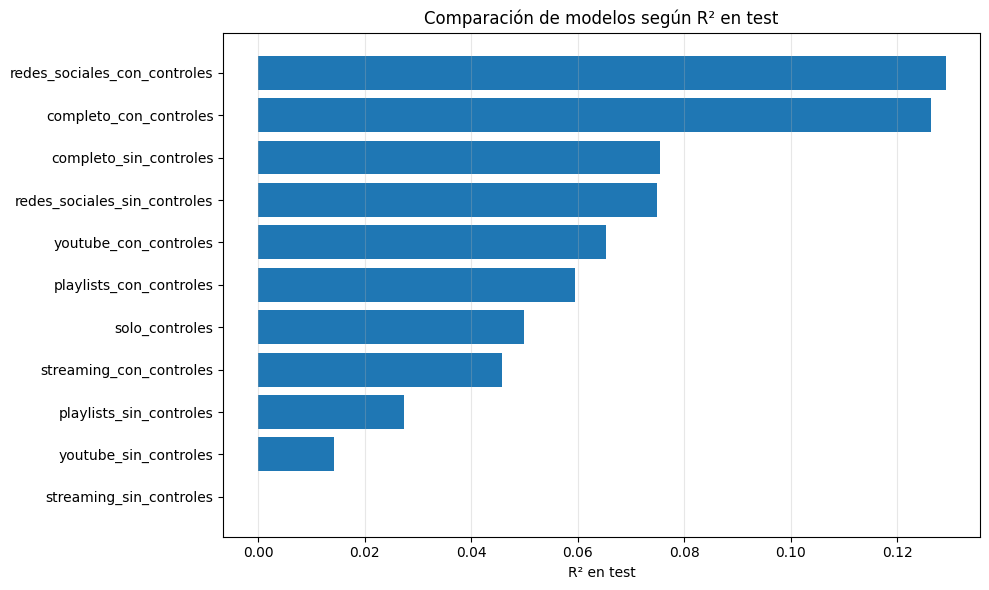

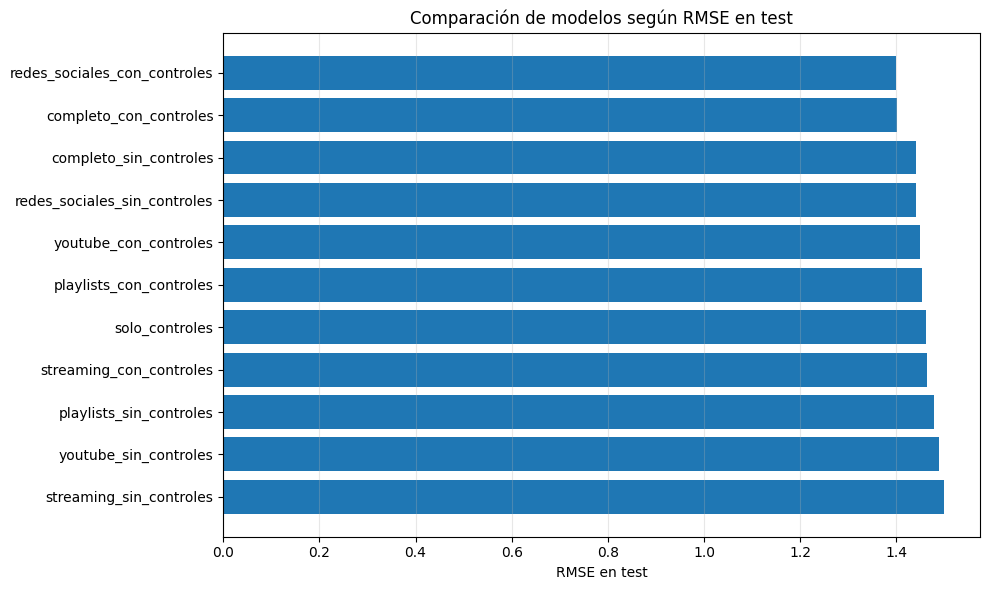

In [32]:
# ============================================================
# Gráficos comparativos de modelos
# ============================================================

import matplotlib.pyplot as plt

tabla_plot = resultados_statsmodels.copy()

tabla_plot = (
    tabla_plot
    .sort_values("r2_test", ascending=True)
    .reset_index(drop=True)
)

plt.figure(figsize=(10, 6))
plt.barh(tabla_plot["modelo"], tabla_plot["r2_test"])
plt.xlabel("R² en test")
plt.ylabel("")
plt.title("Comparación de modelos según R² en test")
plt.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

tabla_plot_rmse = (
    resultados_statsmodels
    .sort_values("rmse_test", ascending=False)
    .reset_index(drop=True)
)

plt.figure(figsize=(10, 6))
plt.barh(tabla_plot_rmse["modelo"], tabla_plot_rmse["rmse_test"])
plt.xlabel("RMSE en test")
plt.ylabel("")
plt.title("Comparación de modelos según RMSE en test")
plt.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

## obs vs predichos y residuos

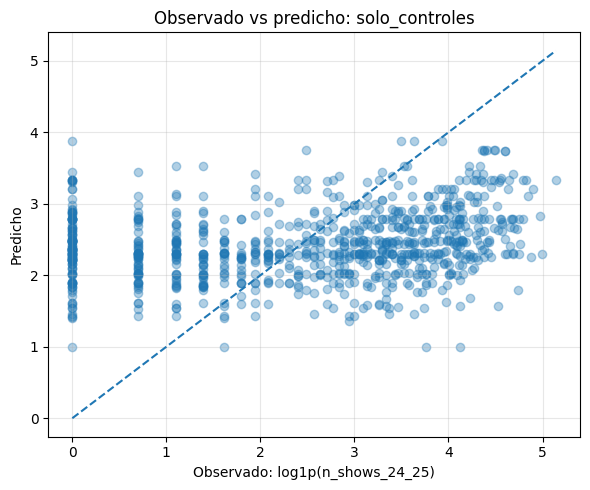

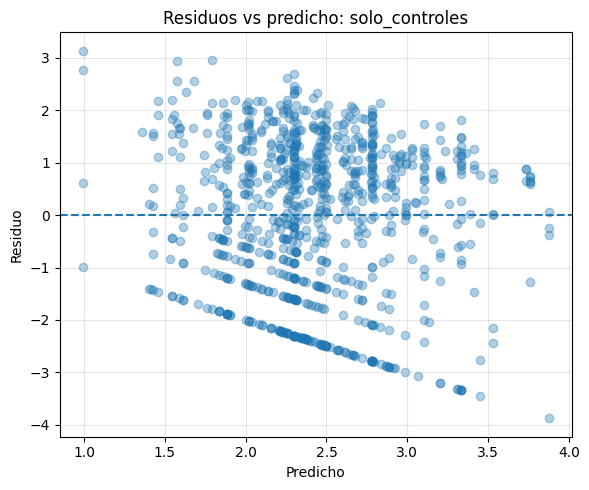

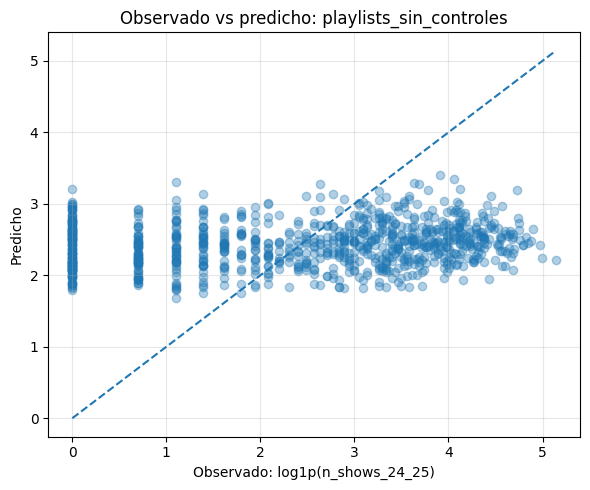

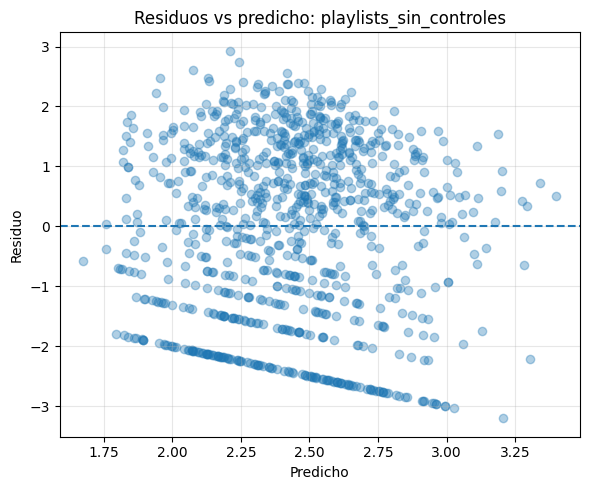

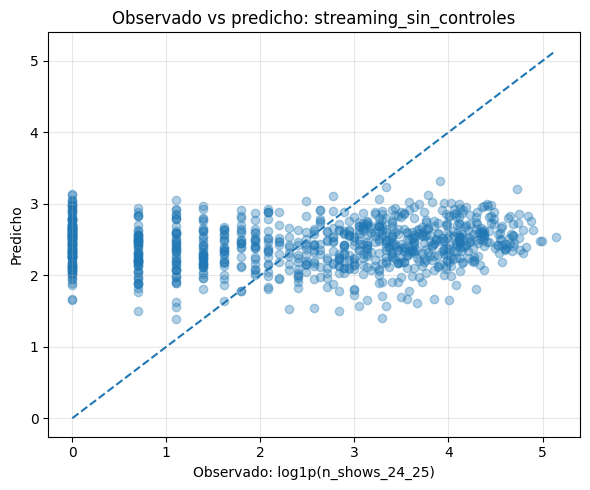

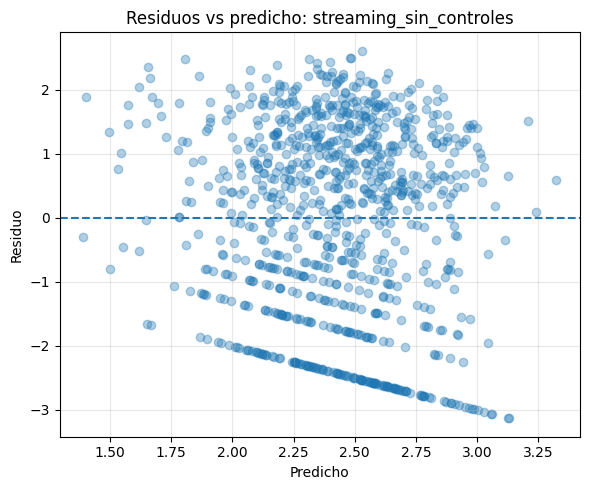

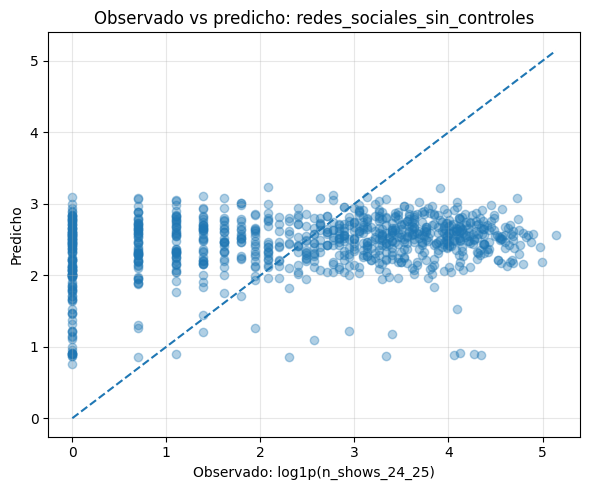

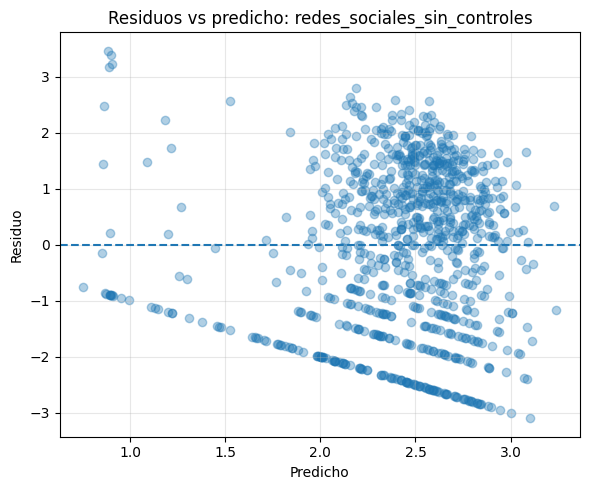

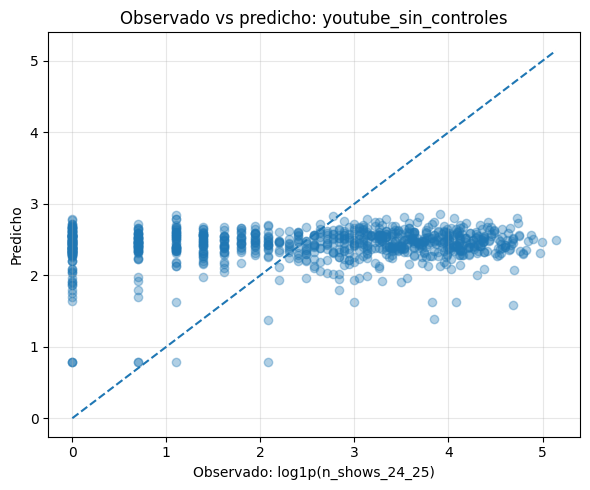

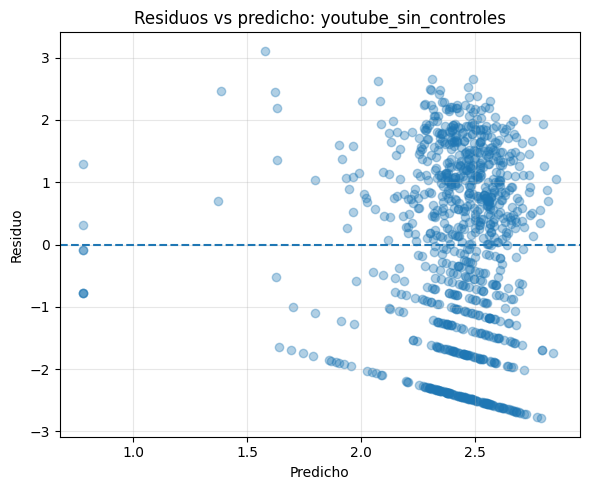

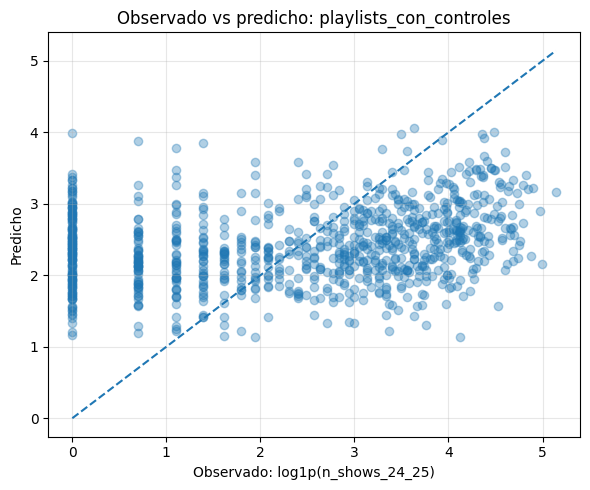

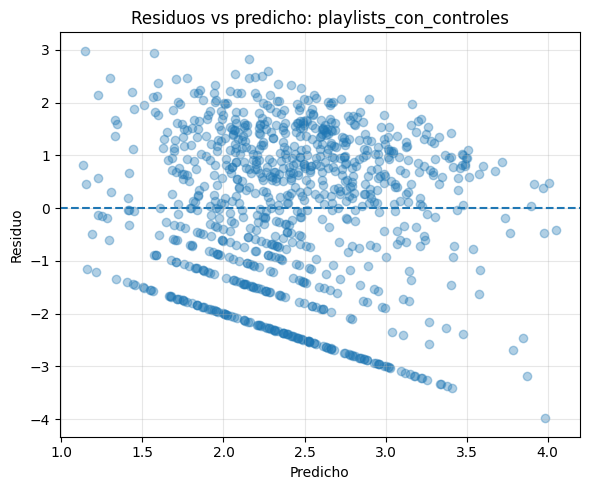

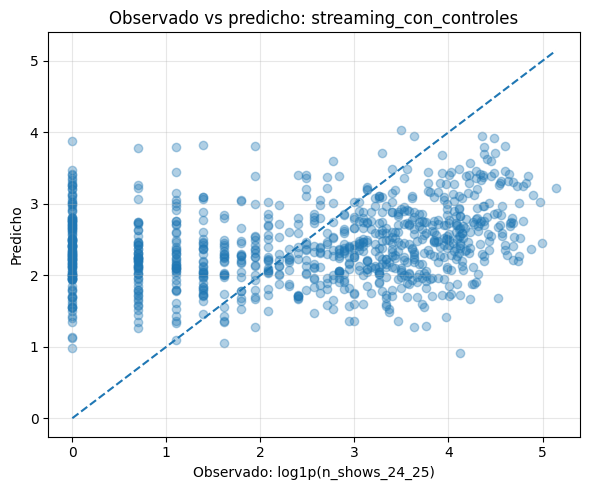

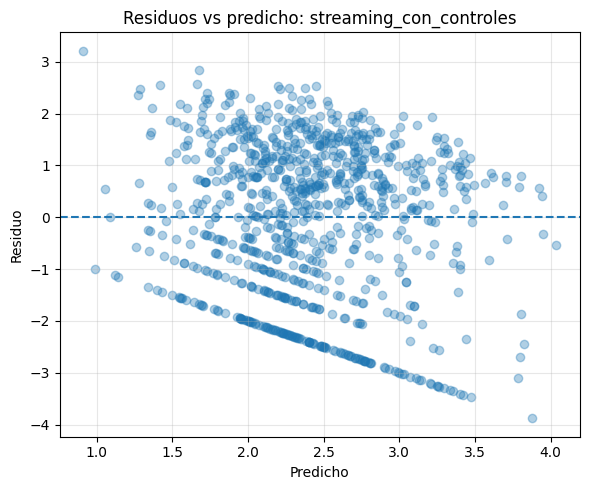

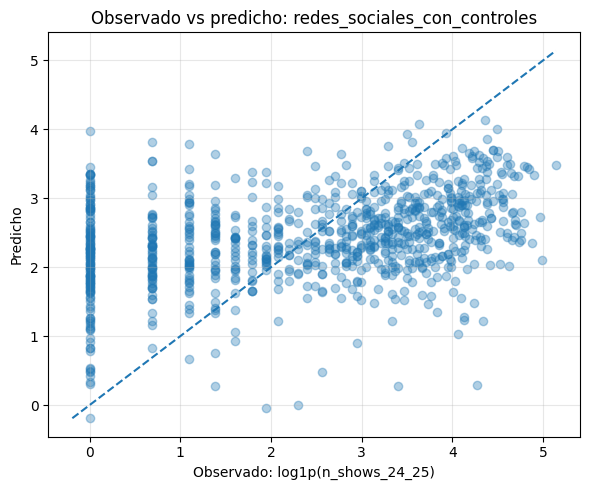

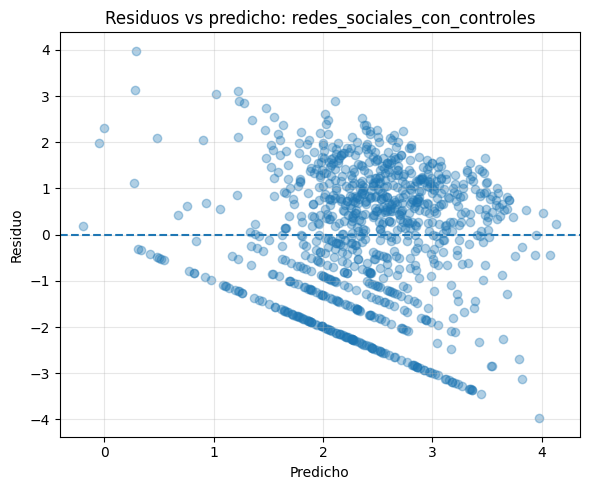

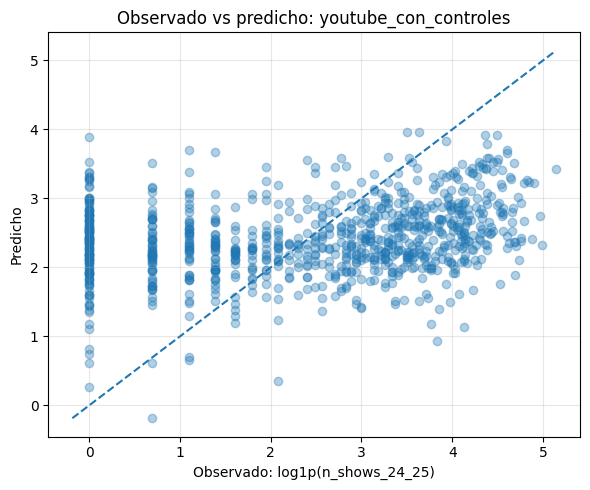

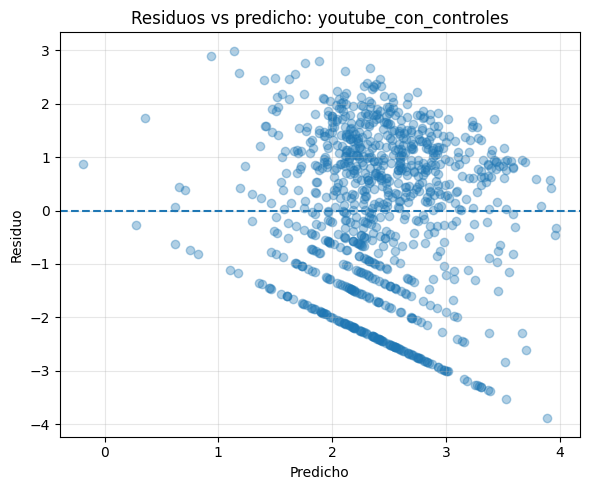

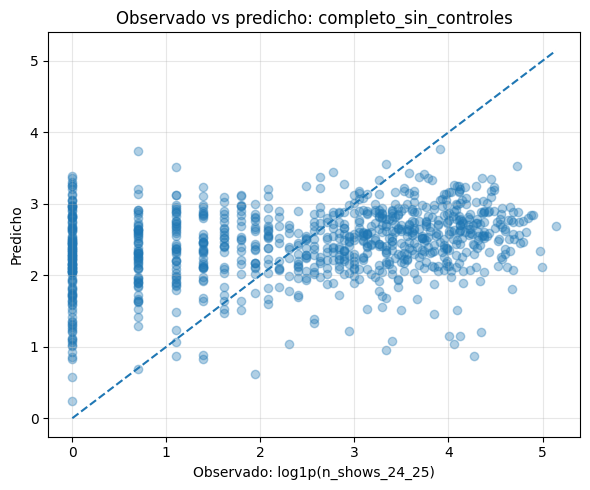

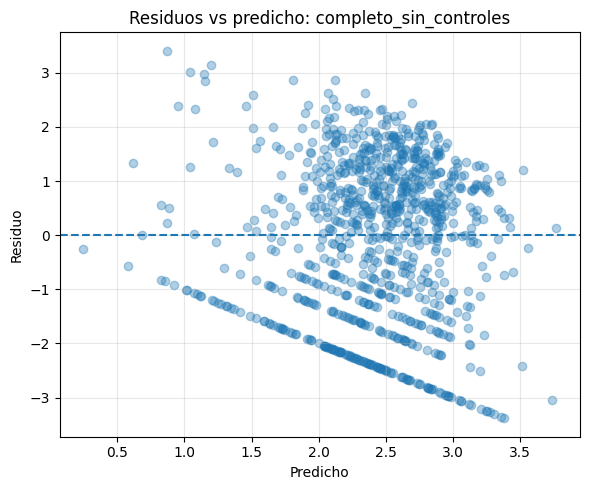

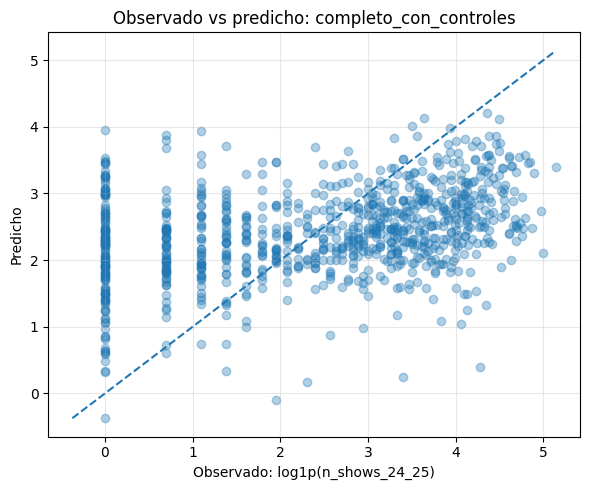

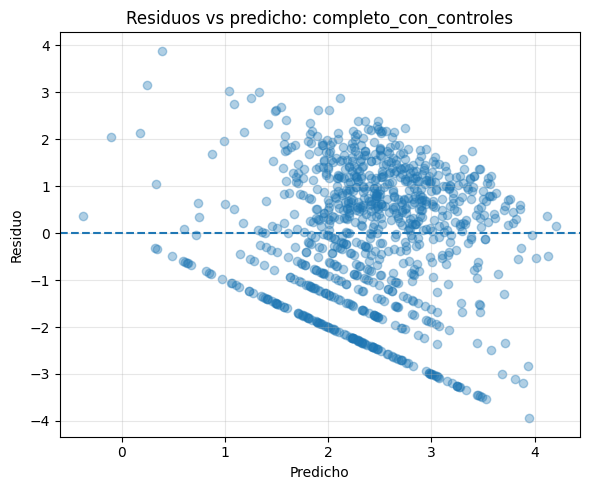

In [33]:
# ============================================================
# Observado vs predicho y residuos para todos los modelos
# ============================================================

predicciones_test_statsmodels = {}

for nombre_modelo, config in modelos_lineales.items():
    
    features_numericas = config["numericas"]
    features_categoricas_modelo = config["categoricas"]
    
    X_train_sm = preparar_matriz_ols(
        X_train_all,
        features_numericas,
        features_categoricas_modelo
    )
    
    X_test_sm = preparar_matriz_ols(
        X_test_all,
        features_numericas,
        features_categoricas_modelo
    )
    
    X_test_sm = X_test_sm.reindex(columns=X_train_sm.columns, fill_value=0)
    
    modelo_sm = modelos_statsmodels[nombre_modelo]
    
    y_pred_test_sm = modelo_sm.predict(X_test_sm)
    residuos_test_sm = y_test - y_pred_test_sm
    
    predicciones_test_statsmodels[nombre_modelo] = pd.DataFrame({
        "y_observado": y_test,
        "y_predicho": y_pred_test_sm,
        "residuo": residuos_test_sm
    })

for nombre_modelo, df_pred in predicciones_test_statsmodels.items():
    
    plt.figure(figsize=(6, 5))
    plt.scatter(df_pred["y_observado"], df_pred["y_predicho"], alpha=0.35)
    
    minimo = min(df_pred["y_observado"].min(), df_pred["y_predicho"].min())
    maximo = max(df_pred["y_observado"].max(), df_pred["y_predicho"].max())
    
    plt.plot([minimo, maximo], [minimo, maximo], linestyle="--")
    plt.xlabel("Observado: log1p(n_shows_24_25)")
    plt.ylabel("Predicho")
    plt.title(f"Observado vs predicho: {nombre_modelo}")
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()
    
    plt.figure(figsize=(6, 5))
    plt.scatter(df_pred["y_predicho"], df_pred["residuo"], alpha=0.35)
    plt.axhline(0, linestyle="--")
    plt.xlabel("Predicho")
    plt.ylabel("Residuo")
    plt.title(f"Residuos vs predicho: {nombre_modelo}")
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()


# Extensión breve: modelos de conteo para `n_shows_24_25`

Esta sección se agrega como complemento metodológico de la regresión lineal ya realizada. Mantiene la misma muestra, el mismo tratamiento de nulos y la misma partición train/test estratificada. El objetivo es contrastar los resultados lineales con modelos más adecuados para una variable de conteo sobredispersa, con masa de ceros y cola larga.

La estrategia incluye dos caminos:

1. Binomial negativa sobre la cantidad cruda de shows.
2. Modelo en dos etapas: ocurrencia de actividad live y, entre artistas con actividad positiva, intensidad de shows mediante binomial negativa.

Para asegurar estabilidad y velocidad de ejecución, se usa `GLM` con familia binomial negativa y parámetro de sobredispersión estimado por método de momentos sobre el target de entrenamiento. Esta solución es robusta para una extensión breve dentro de la tesis y evita problemas de convergencia frecuentes en modelos MLE con muchas dummies categóricas.


In [34]:

# ============================================================
# Sanity check de objetos heredados del workflow previo
# ============================================================

objetos_requeridos_conteo = [
    "df_modelo_lineal_imp",
    "X_train_all",
    "X_test_all",
    "y_train",
    "y_test",
    "modelos_lineales",
    "modelos_statsmodels",
    "preparar_matriz_ols"
]

objetos_faltantes_conteo = [
    nombre_objeto
    for nombre_objeto in objetos_requeridos_conteo
    if nombre_objeto not in globals()
]

if len(objetos_faltantes_conteo) > 0:
    raise RuntimeError(
        "Faltan objetos del workflow previo: "
        + ", ".join(objetos_faltantes_conteo)
    )

print("Objetos requeridos disponibles para la extensión de conteo.")
print("Train:", X_train_all.shape)
print("Test:", X_test_all.shape)


Objetos requeridos disponibles para la extensión de conteo.
Train: (3604, 14)
Test: (901, 14)


In [35]:

# ============================================================
# Targets en escala de conteo y control de sobredispersión
# ============================================================

import statsmodels.api as sm
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# ------------------------------------------------------------
# Recuperación de escala original desde el target logarítmico
# ------------------------------------------------------------

y_train_count = np.rint(np.expm1(y_train)).astype(int)
y_test_count = np.rint(np.expm1(y_test)).astype(int)

y_train_ocurrencia = (y_train_count > 0).astype(int)
y_test_ocurrencia = (y_test_count > 0).astype(int)

media_train_count = float(y_train_count.mean())
varianza_train_count = float(y_train_count.var())

alpha_nb_global = max(
    (varianza_train_count - media_train_count) / (media_train_count ** 2),
    1e-6
)

mascara_train_positivos = y_train_count > 0
y_train_count_positivos = y_train_count[mascara_train_positivos]

media_train_positivos = float(y_train_count_positivos.mean())
varianza_train_positivos = float(y_train_count_positivos.var())

alpha_nb_positivos = max(
    (varianza_train_positivos - media_train_positivos) / (media_train_positivos ** 2),
    1e-6
)

resumen_target_conteo = pd.DataFrame({
    "muestra": ["train", "test", "train_positivos"],
    "n_artistas": [
        len(y_train_count),
        len(y_test_count),
        int(mascara_train_positivos.sum())
    ],
    "pct_cero_shows": [
        round((y_train_count == 0).mean() * 100, 2),
        round((y_test_count == 0).mean() * 100, 2),
        0.0
    ],
    "media_shows": [
        round(media_train_count, 2),
        round(float(y_test_count.mean()), 2),
        round(media_train_positivos, 2)
    ],
    "varianza_shows": [
        round(varianza_train_count, 2),
        round(float(y_test_count.var()), 2),
        round(varianza_train_positivos, 2)
    ],
    "mediana_shows": [
        float(np.median(y_train_count)),
        float(np.median(y_test_count)),
        float(np.median(y_train_count_positivos))
    ],
    "p90_shows": [
        float(np.percentile(y_train_count, 90)),
        float(np.percentile(y_test_count, 90)),
        float(np.percentile(y_train_count_positivos, 90))
    ],
    "max_shows": [
        int(y_train_count.max()),
        int(y_test_count.max()),
        int(y_train_count_positivos.max())
    ]
})

resumen_target_conteo["varianza_media_ratio"] = (
    resumen_target_conteo["varianza_shows"]
    / resumen_target_conteo["media_shows"]
).round(2)

print("Alpha binomial negativa global:", round(alpha_nb_global, 4))
print("Alpha binomial negativa en positivos:", round(alpha_nb_positivos, 4))
display(resumen_target_conteo)


Alpha binomial negativa global: 1.3297
Alpha binomial negativa en positivos: 0.978


,muestra,n_artistas,pct_cero_shows,media_shows,varianza_shows,mediana_shows,p90_shows,max_shows,varianza_media_ratio
0,train,3604,15.09,25.86,915.21,15.0,71.0,179,35.39
1,test,901,15.09,25.37,852.30,15.0,68.0,170,33.59
2,train_positivos,3060,0.00,30.46,937.88,21.0,75.0,179,30.79


In [36]:

# ============================================================
# Funciones auxiliares para modelos de conteo
# ============================================================

def preparar_matriz_conteo(X_base, features_numericas, features_categoricas, columnas_referencia=None):
    
    X_modelo = X_base[features_numericas + features_categoricas].copy()
    
    if len(features_categoricas) > 0:
        X_modelo = pd.get_dummies(
            X_modelo,
            columns=features_categoricas,
            drop_first=True,
            dtype=float
        )
    
    for col in X_modelo.columns:
        X_modelo[col] = X_modelo[col].astype(float)
    
    X_modelo = sm.add_constant(X_modelo, has_constant="add")
    
    if columnas_referencia is not None:
        X_modelo = X_modelo.reindex(columns=columnas_referencia, fill_value=0)
    
    return X_modelo


def calcular_metricas_conteo(y_real, y_pred):
    
    y_pred_clip = np.clip(np.asarray(y_pred, dtype=float), 0, None)
    
    return {
        "mae_count": mean_absolute_error(y_real, y_pred_clip),
        "rmse_count": mean_squared_error(y_real, y_pred_clip) ** 0.5,
        "r2_count": r2_score(y_real, y_pred_clip)
    }


def construir_tabla_coeficientes(modelo, nombre_modelo, familia_modelo):
    
    tabla_coeficientes = pd.DataFrame({
        "modelo": nombre_modelo,
        "familia_modelo": familia_modelo,
        "variable": modelo.params.index,
        "coeficiente": modelo.params.values,
        "p_value": modelo.pvalues.values
    })
    
    tabla_coeficientes["significativa_005"] = tabla_coeficientes["p_value"] < 0.05
    tabla_coeficientes["significativa_010"] = tabla_coeficientes["p_value"] < 0.10
    
    return tabla_coeficientes



## 1. Binomial negativa sobre conteos crudos

Este bloque estima los mismos modelos conceptuales del análisis lineal, pero usando `n_shows_24_25` en escala de conteo. La binomial negativa permite modelar sobredispersión, es decir, casos donde la varianza de la cantidad de shows es mucho mayor que la media.


In [37]:

# ============================================================
# Ajuste de modelos GLM binomial negativa
# ============================================================

modelos_binomial_negativa = {}
resultados_binomial_negativa = []
coeficientes_binomial_negativa = []

for nombre_modelo, config in modelos_lineales.items():
    
    features_numericas = config["numericas"]
    features_categoricas_modelo = config["categoricas"]
    
    X_train_nb = preparar_matriz_conteo(
        X_train_all,
        features_numericas,
        features_categoricas_modelo
    )
    
    X_test_nb = preparar_matriz_conteo(
        X_test_all,
        features_numericas,
        features_categoricas_modelo,
        columnas_referencia=X_train_nb.columns
    )
    
    modelo_nb = sm.GLM(
        y_train_count,
        X_train_nb,
        family=sm.families.NegativeBinomial(alpha=alpha_nb_global)
    ).fit()
    
    y_pred_train_nb = modelo_nb.predict(X_train_nb)
    y_pred_test_nb = modelo_nb.predict(X_test_nb)
    
    metricas_train = calcular_metricas_conteo(y_train_count, y_pred_train_nb)
    metricas_test = calcular_metricas_conteo(y_test_count, y_pred_test_nb)
    
    modelos_binomial_negativa[nombre_modelo] = modelo_nb
    coeficientes_binomial_negativa.append(
        construir_tabla_coeficientes(
            modelo_nb,
            nombre_modelo,
            "binomial_negativa_glm"
        )
    )
    
    resultados_binomial_negativa.append({
        "modelo": nombre_modelo,
        "n_parametros": int(modelo_nb.df_model + 1),
        "aic": modelo_nb.aic,
        "bic": modelo_nb.bic_llf,
        "alpha_usado": alpha_nb_global,
        "mae_train_count": metricas_train["mae_count"],
        "rmse_train_count": metricas_train["rmse_count"],
        "r2_train_count": metricas_train["r2_count"],
        "mae_test_count": metricas_test["mae_count"],
        "rmse_test_count": metricas_test["rmse_count"],
        "r2_test_count": metricas_test["r2_count"],
        "n_coef_significativos_005": int((modelo_nb.pvalues < 0.05).sum()),
        "n_coef_significativos_010": int((modelo_nb.pvalues < 0.10).sum())
    })

resultados_binomial_negativa = pd.DataFrame(resultados_binomial_negativa)
coeficientes_binomial_negativa = pd.concat(
    coeficientes_binomial_negativa,
    ignore_index=True
)

resultados_binomial_negativa_ordenada = (
    resultados_binomial_negativa
    .sort_values(["mae_test_count", "rmse_test_count"], ascending=[True, True])
    .reset_index(drop=True)
)

display(resultados_binomial_negativa_ordenada.round(4))


,modelo,n_parametros,aic,bic,alpha_usado,mae_train_count,rmse_train_count,r2_train_count,mae_test_count,rmse_test_count,r2_test_count,n_coef_significativos_005,n_coef_significativos_010
0,redes_sociales_con_controles,25,29340.2065,29494.9515,1.3297,20.0709,27.0897,0.1979,20.3802,27.2941,0.1250,14,16
1,completo_con_controles,31,29292.1754,29484.0592,1.3297,19.9906,27.2313,0.1895,20.6314,27.8407,0.0896,17,18
2,youtube_con_controles,23,29490.4273,29632.7927,1.3297,20.5332,27.2986,0.1855,20.8575,27.4897,0.1124,13,13
3,solo_controles,22,29581.7057,29717.8813,1.3297,20.9145,27.5779,0.1688,21.1004,27.4688,0.1137,12,13
4,playlists_con_controles,24,29480.5553,29629.1105,1.3297,20.6798,27.5782,0.1688,21.1260,27.9871,0.0800,14,15
5,streaming_con_controles,25,29465.3385,29620.0835,1.3297,20.6014,27.4639,0.1756,21.1981,27.9855,0.0801,14,14
6,completo_sin_controles,10,29683.8373,29745.7353,1.3297,21.6610,28.8016,0.0934,21.8834,28.6493,0.0359,7,7
7,redes_sociales_sin_controles,4,29978.0780,30002.8372,1.3297,23.1084,29.9183,0.0217,22.4535,28.9041,0.0187,4,4
8,streaming_sin_controles,4,29839.4917,29864.2509,1.3297,22.2397,29.0996,0.0745,22.4818,28.7964,0.0260,3,4
9,playlists_sin_controles,3,29983.9986,30002.5680,1.3297,22.8486,29.6609,0.0385,22.6840,28.9610,0.0148,3,3


In [38]:

# ============================================================
# Coeficientes y significancia de binomial negativa
# ============================================================

coeficientes_nb_reporte = coeficientes_binomial_negativa.copy()

coeficientes_nb_reporte["incidence_rate_ratio"] = np.exp(
    coeficientes_nb_reporte["coeficiente"]
)

coeficientes_nb_reporte = (
    coeficientes_nb_reporte
    .sort_values(["modelo", "p_value"])
    .reset_index(drop=True)
)

display(
    coeficientes_nb_reporte[
        [
            "modelo",
            "variable",
            "coeficiente",
            "incidence_rate_ratio",
            "p_value",
            "significativa_005",
            "significativa_010"
        ]
    ].round(4)
)


,modelo,variable,coeficiente,incidence_rate_ratio,p_value,significativa_005,significativa_010
0,completo_con_controles,log1p_ins_followers_imp,0.0791,1.0823,0.0000,True,True
1,completo_con_controles,genre_short_Regional global,-1.1714,0.3099,0.0000,True,True
2,completo_con_controles,genre_short_Latin & urban,-0.8024,0.4483,0.0000,True,True
3,completo_con_controles,genre_short_Hip-hop & trap,-0.6179,0.5391,0.0000,True,True
4,completo_con_controles,genre_short_Pop,-0.3985,0.6713,0.0000,True,True
...,...,...,...,...,...,...,...
168,youtube_con_controles,country_short_imp_Asia & Oceania,-0.0268,0.9735,0.8306,False,False
169,youtube_con_controles,genre_short_Rock & metal,-0.0117,0.9883,0.8989,False,False
170,youtube_con_controles,pronoun_short_they/them,-0.0214,0.9788,0.9587,False,False
171,youtube_sin_controles,const,2.0362,7.6614,0.0000,True,True



## 2. Arquitectura de dos etapas

La segunda estrategia separa dos procesos conceptualmente distintos. Primero estima la probabilidad de registrar al menos un show en 2024-2025. Luego, entre artistas con actividad positiva, estima la intensidad de shows mediante binomial negativa. La predicción final esperada se calcula como:

`E(shows) = P(shows > 0) * E(shows | shows > 0)`


In [39]:

# ============================================================
# Ajuste de modelos en dos etapas
# ============================================================

modelos_dos_etapas = {}
resultados_dos_etapas = []
coeficientes_ocurrencia = []
coeficientes_intensidad_positiva = []

X_train_all_positivos = X_train_all.loc[mascara_train_positivos].copy()

for nombre_modelo, config in modelos_lineales.items():
    
    features_numericas = config["numericas"]
    features_categoricas_modelo = config["categoricas"]
    
    X_train_etapa_1 = preparar_matriz_conteo(
        X_train_all,
        features_numericas,
        features_categoricas_modelo
    )
    
    X_test_etapa_1 = preparar_matriz_conteo(
        X_test_all,
        features_numericas,
        features_categoricas_modelo,
        columnas_referencia=X_train_etapa_1.columns
    )
    
    modelo_ocurrencia = sm.GLM(
        y_train_ocurrencia,
        X_train_etapa_1,
        family=sm.families.Binomial()
    ).fit()
    
    X_train_etapa_2 = preparar_matriz_conteo(
        X_train_all_positivos,
        features_numericas,
        features_categoricas_modelo
    )
    
    X_test_etapa_2 = preparar_matriz_conteo(
        X_test_all,
        features_numericas,
        features_categoricas_modelo,
        columnas_referencia=X_train_etapa_2.columns
    )
    
    X_train_etapa_2_todos = preparar_matriz_conteo(
        X_train_all,
        features_numericas,
        features_categoricas_modelo,
        columnas_referencia=X_train_etapa_2.columns
    )
    
    modelo_intensidad = sm.GLM(
        y_train_count_positivos,
        X_train_etapa_2,
        family=sm.families.NegativeBinomial(alpha=alpha_nb_positivos)
    ).fit()
    
    prob_train = modelo_ocurrencia.predict(X_train_etapa_1)
    prob_test = modelo_ocurrencia.predict(X_test_etapa_1)
    
    intensidad_train = modelo_intensidad.predict(X_train_etapa_2_todos)
    intensidad_test = modelo_intensidad.predict(X_test_etapa_2)
    
    y_pred_train_dos_etapas = prob_train * intensidad_train
    y_pred_test_dos_etapas = prob_test * intensidad_test
    
    metricas_train = calcular_metricas_conteo(y_train_count, y_pred_train_dos_etapas)
    metricas_test = calcular_metricas_conteo(y_test_count, y_pred_test_dos_etapas)
    
    modelos_dos_etapas[nombre_modelo] = {
        "ocurrencia": modelo_ocurrencia,
        "intensidad_positiva": modelo_intensidad
    }
    
    coeficientes_ocurrencia.append(
        construir_tabla_coeficientes(
            modelo_ocurrencia,
            nombre_modelo,
            "dos_etapas_ocurrencia_logit"
        )
    )
    
    coeficientes_intensidad_positiva.append(
        construir_tabla_coeficientes(
            modelo_intensidad,
            nombre_modelo,
            "dos_etapas_intensidad_nb_positivos"
        )
    )
    
    resultados_dos_etapas.append({
        "modelo": nombre_modelo,
        "n_train_positivos_etapa_2": int(mascara_train_positivos.sum()),
        "aic_ocurrencia": modelo_ocurrencia.aic,
        "bic_ocurrencia": modelo_ocurrencia.bic_llf,
        "aic_intensidad_positiva": modelo_intensidad.aic,
        "bic_intensidad_positiva": modelo_intensidad.bic_llf,
        "alpha_intensidad_positiva": alpha_nb_positivos,
        "mae_train_count": metricas_train["mae_count"],
        "rmse_train_count": metricas_train["rmse_count"],
        "r2_train_count": metricas_train["r2_count"],
        "mae_test_count": metricas_test["mae_count"],
        "rmse_test_count": metricas_test["rmse_count"],
        "r2_test_count": metricas_test["r2_count"],
        "n_sig_ocurrencia_005": int((modelo_ocurrencia.pvalues < 0.05).sum()),
        "n_sig_intensidad_005": int((modelo_intensidad.pvalues < 0.05).sum())
    })

resultados_dos_etapas = pd.DataFrame(resultados_dos_etapas)
coeficientes_ocurrencia = pd.concat(coeficientes_ocurrencia, ignore_index=True)
coeficientes_intensidad_positiva = pd.concat(coeficientes_intensidad_positiva, ignore_index=True)

resultados_dos_etapas_ordenada = (
    resultados_dos_etapas
    .sort_values(["mae_test_count", "rmse_test_count"], ascending=[True, True])
    .reset_index(drop=True)
)

display(resultados_dos_etapas_ordenada.round(4))


,modelo,n_train_positivos_etapa_2,aic_ocurrencia,bic_ocurrencia,aic_intensidad_positiva,bic_intensidad_positiva,alpha_intensidad_positiva,mae_train_count,rmse_train_count,r2_train_count,mae_test_count,rmse_test_count,r2_test_count,n_sig_ocurrencia_005,n_sig_intensidad_005
0,redes_sociales_con_controles,3060,2692.7204,2847.4654,26418.1139,26568.7682,0.978,20.0395,26.9774,0.2046,20.3344,27.1900,0.1316,9,15
1,completo_con_controles,3060,2674.8229,2866.7067,26333.8639,26520.6752,0.978,19.9232,27.0726,0.1990,20.5593,27.6887,0.0995,10,14
2,youtube_con_controles,3060,2929.9927,3072.3581,26430.0143,26568.6163,0.978,20.5236,27.2809,0.1866,20.8416,27.4703,0.1136,13,12
3,solo_controles,3060,2954.8385,3091.0141,26494.4629,26627.0386,0.978,20.9067,27.5666,0.1695,21.1120,27.4773,0.1132,11,11
4,playlists_con_controles,3060,2942.8830,3091.4382,26402.5746,26547.2027,0.978,20.6679,27.5653,0.1695,21.1381,27.9739,0.0808,12,13
5,streaming_con_controles,3060,2932.9495,3087.6945,26359.1293,26509.7836,0.978,20.5929,27.4713,0.1752,21.2082,27.9947,0.0795,12,12
6,completo_sin_controles,3060,2731.3235,2793.2214,26717.4016,26777.6633,0.978,21.5390,28.6462,0.1031,21.8135,28.5050,0.0456,4,5
7,redes_sociales_sin_controles,3060,2749.0293,2773.7885,27119.1582,27143.2629,0.978,22.9989,29.7731,0.0312,22.3961,28.7435,0.0296,3,2
8,streaming_sin_controles,3060,3026.1882,3050.9474,26764.9516,26789.0563,0.978,22.2413,29.1077,0.0740,22.4741,28.7929,0.0262,2,4
9,playlists_sin_controles,3060,3042.6947,3061.2641,27017.0352,27035.1137,0.978,22.8497,29.6561,0.0388,22.6650,28.9381,0.0164,2,3


In [40]:

# ============================================================
# Coeficientes y significancia de la etapa 1: ocurrencia live
# ============================================================

coeficientes_ocurrencia_reporte = coeficientes_ocurrencia.copy()

coeficientes_ocurrencia_reporte["odds_ratio"] = np.exp(
    coeficientes_ocurrencia_reporte["coeficiente"]
)

coeficientes_ocurrencia_reporte = (
    coeficientes_ocurrencia_reporte
    .sort_values(["modelo", "p_value"])
    .reset_index(drop=True)
)

display(
    coeficientes_ocurrencia_reporte[
        [
            "modelo",
            "variable",
            "coeficiente",
            "odds_ratio",
            "p_value",
            "significativa_005",
            "significativa_010"
        ]
    ].round(4)
)


,modelo,variable,coeficiente,odds_ratio,p_value,significativa_005,significativa_010
0,completo_con_controles,log1p_ins_followers_imp,0.1618,1.1756,0.0000,True,True
1,completo_con_controles,log1p_twitter_followers_imp,0.0652,1.0673,0.0000,True,True
2,completo_con_controles,log1p_pandora_lifetime_streams_imp,-0.1091,0.8966,0.0000,True,True
3,completo_con_controles,genre_short_Jazz & blues & classical,-1.8007,0.1652,0.0000,True,True
4,completo_con_controles,genre_short_Pop,-1.3182,0.2676,0.0000,True,True
...,...,...,...,...,...,...,...
168,youtube_con_controles,pronoun_short_he/him,-0.2320,0.7929,0.8296,False,False
169,youtube_con_controles,pronoun_short_they/them,-0.2112,0.8096,0.8503,False,False
170,youtube_con_controles,band_True,0.0579,1.0596,0.8742,False,False
171,youtube_sin_controles,log1p_ycs_views_imp,0.0836,1.0872,0.0000,True,True


In [41]:

# ============================================================
# Coeficientes y significancia de la etapa 2: intensidad positiva
# ============================================================

coeficientes_intensidad_reporte = coeficientes_intensidad_positiva.copy()

coeficientes_intensidad_reporte["incidence_rate_ratio"] = np.exp(
    coeficientes_intensidad_reporte["coeficiente"]
)

coeficientes_intensidad_reporte = (
    coeficientes_intensidad_reporte
    .sort_values(["modelo", "p_value"])
    .reset_index(drop=True)
)

display(
    coeficientes_intensidad_reporte[
        [
            "modelo",
            "variable",
            "coeficiente",
            "incidence_rate_ratio",
            "p_value",
            "significativa_005",
            "significativa_010"
        ]
    ].round(4)
)


,modelo,variable,coeficiente,incidence_rate_ratio,p_value,significativa_005,significativa_010
0,completo_con_controles,genre_short_Regional global,-0.9929,0.3705,0.0000,True,True
1,completo_con_controles,genre_short_Hip-hop & trap,-0.5668,0.5674,0.0000,True,True
2,completo_con_controles,genre_short_Latin & urban,-0.6955,0.4988,0.0000,True,True
3,completo_con_controles,log1p_pandora_lifetime_streams_imp,0.0394,1.0402,0.0000,True,True
4,completo_con_controles,genre_short_Electronic & dance,-0.3953,0.6735,0.0000,True,True
...,...,...,...,...,...,...,...
168,youtube_con_controles,country_short_imp_LATAM,0.0229,1.0232,0.8426,False,False
169,youtube_con_controles,pronoun_short_he/him,-0.0575,0.9441,0.8728,False,False
170,youtube_con_controles,pronoun_short_they/them,-0.0018,0.9982,0.9961,False,False
171,youtube_sin_controles,const,2.5011,12.1956,0.0000,True,True



## 3. Comparación sintética con los modelos lineales previos

La comparación se presenta en escala de conteo para que todos los modelos queden evaluados sobre la misma variable sustantiva: cantidad esperada de shows. Para los modelos OLS estimados sobre `log1p(n_shows_24_25)`, las predicciones se transforman de vuelta con `expm1` y se recortan en cero.


In [42]:

# ============================================================
# Comparación de OLS, binomial negativa y dos etapas
# ============================================================

resultados_ols_count = []

for nombre_modelo, config in modelos_lineales.items():
    
    features_numericas = config["numericas"]
    features_categoricas_modelo = config["categoricas"]
    
    X_train_sm = preparar_matriz_ols(
        X_train_all,
        features_numericas,
        features_categoricas_modelo
    )
    
    X_test_sm = preparar_matriz_ols(
        X_test_all,
        features_numericas,
        features_categoricas_modelo
    )
    
    X_test_sm = X_test_sm.reindex(columns=X_train_sm.columns, fill_value=0)
    
    modelo_ols = modelos_statsmodels[nombre_modelo]
    y_pred_test_log = modelo_ols.predict(X_test_sm)
    y_pred_test_count = np.clip(np.expm1(y_pred_test_log), 0, None)
    
    metricas_test = calcular_metricas_conteo(y_test_count, y_pred_test_count)
    
    resultados_ols_count.append({
        "familia_modelo": "OLS_log1p_retransformado",
        "modelo": nombre_modelo,
        "mae_test_count": metricas_test["mae_count"],
        "rmse_test_count": metricas_test["rmse_count"],
        "r2_test_count": metricas_test["r2_count"],
        "aic": modelo_ols.aic,
        "bic": modelo_ols.bic
    })

resultados_ols_count = pd.DataFrame(resultados_ols_count)

comparacion_nb_count = resultados_binomial_negativa.assign(
    familia_modelo="binomial_negativa_glm"
)[[
    "familia_modelo",
    "modelo",
    "mae_test_count",
    "rmse_test_count",
    "r2_test_count",
    "aic",
    "bic"
]]

comparacion_dos_etapas_count = resultados_dos_etapas.assign(
    familia_modelo="dos_etapas"
)[[
    "familia_modelo",
    "modelo",
    "mae_test_count",
    "rmse_test_count",
    "r2_test_count",
    "aic_intensidad_positiva",
    "bic_intensidad_positiva"
]].rename(columns={
    "aic_intensidad_positiva": "aic",
    "bic_intensidad_positiva": "bic"
})

comparacion_modelos_conteo = pd.concat(
    [
        resultados_ols_count,
        comparacion_nb_count,
        comparacion_dos_etapas_count
    ],
    ignore_index=True
)

comparacion_modelos_conteo = (
    comparacion_modelos_conteo
    .sort_values(["mae_test_count", "rmse_test_count"], ascending=[True, True])
    .reset_index(drop=True)
)

display(comparacion_modelos_conteo.round(4))


,familia_modelo,modelo,mae_test_count,rmse_test_count,r2_test_count,aic,bic
0,OLS_log1p_retransformado,redes_sociales_con_controles,19.9031,29.9716,-0.0551,12533.4163,12688.1613
1,OLS_log1p_retransformado,completo_con_controles,19.9282,30.0295,-0.0592,12510.8303,12702.7141
2,dos_etapas,redes_sociales_con_controles,20.3344,27.1900,0.1316,26418.1139,26568.7682
3,binomial_negativa_glm,redes_sociales_con_controles,20.3802,27.2941,0.1250,29340.2065,29494.9515
4,dos_etapas,completo_con_controles,20.5593,27.6887,0.0995,26333.8639,26520.6752
5,binomial_negativa_glm,completo_con_controles,20.6314,27.8407,0.0896,29292.1754,29484.0592
6,OLS_log1p_retransformado,youtube_con_controles,20.6334,30.7014,-0.1072,12779.7998,12922.1652
7,OLS_log1p_retransformado,playlists_con_controles,20.6850,30.7840,-0.1131,12792.5177,12941.0729
8,OLS_log1p_retransformado,solo_controles,20.7739,30.8833,-0.1203,12876.1787,13012.3542
9,OLS_log1p_retransformado,streaming_con_controles,20.8330,30.8443,-0.1175,12806.2313,12960.9763


In [43]:

# ============================================================
# Resumen ejecutivo de mejores modelos por familia
# ============================================================

mejor_por_familia_conteo = (
    comparacion_modelos_conteo
    .sort_values(["familia_modelo", "mae_test_count", "rmse_test_count"])
    .groupby("familia_modelo", as_index=False)
    .first()
    .sort_values("mae_test_count")
    .reset_index(drop=True)
)

display(mejor_por_familia_conteo.round(4))


,familia_modelo,modelo,mae_test_count,rmse_test_count,r2_test_count,aic,bic
0,OLS_log1p_retransformado,redes_sociales_con_controles,19.9031,29.9716,-0.0551,12533.4163,12688.1613
1,dos_etapas,redes_sociales_con_controles,20.3344,27.1900,0.1316,26418.1139,26568.7682
2,binomial_negativa_glm,redes_sociales_con_controles,20.3802,27.2941,0.1250,29340.2065,29494.9515


In [44]:

# ============================================================
# Summaries completos de modelos seleccionados
# ============================================================

modelos_para_summary_conteo = [
    "solo_controles",
    "redes_sociales_con_controles",
    "completo_con_controles"
]

for nombre_modelo in modelos_para_summary_conteo:
    
    print("\n" + "=" * 90)
    print("Binomial negativa GLM -", nombre_modelo)
    print("=" * 90)
    display(modelos_binomial_negativa[nombre_modelo].summary())
    
    print("\n" + "=" * 90)
    print("Dos etapas - ocurrencia live -", nombre_modelo)
    print("=" * 90)
    display(modelos_dos_etapas[nombre_modelo]["ocurrencia"].summary())
    
    print("\n" + "=" * 90)
    print("Dos etapas - intensidad positiva -", nombre_modelo)
    print("=" * 90)
    display(modelos_dos_etapas[nombre_modelo]["intensidad_positiva"].summary())



Binomial negativa GLM - solo_controles


<class 'statsmodels.iolib.summary.Summary'>
"""
                  Generalized Linear Model Regression Results                  
===============================================================================
Dep. Variable:     log1p_n_shows_24_25   No. Observations:                 3604
Model:                             GLM   Df Residuals:                     3582
Model Family:         NegativeBinomial   Df Model:                           21
Link Function:                     Log   Scale:                          1.0000
Method:                           IRLS   Log-Likelihood:                -14769.
Date:                 Wed, 10 Jun 2026   Deviance:                       5390.5
Time:                         14:44:22   Pearson chi2:                 3.25e+03
No. Iterations:                      9   Pseudo R-squ. (CS):             0.1509
Covariance Type:             nonrobust                                         
=========================================================================================================
                                            coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------------------
const                                     3.3660      0.415      8.102      0.000       2.552       4.180
country_short_imp_Asia & Oceania         -0.0190      0.125     -0.152      0.879      -0.264       0.226
country_short_imp_Europe_sinGB           -0.2075      0.116     -1.792      0.073      -0.434       0.019
country_short_imp_Great Britain           0.0508      0.119      0.426      0.670      -0.183       0.284
country_short_imp_LATAM                   0.0068      0.125      0.054      0.957      -0.238       0.252
country_short_imp_North America           0.3673      0.109      3.366      0.001       0.153       0.581
genre_short_Country & folk                0.3568      0.108      3.307      0.001       0.145       0.568
genre_short_Electronic & dance           -0.3450      0.092     -3.730      0.000      -0.526      -0.164
genre_short_Hip-hop & trap               -0.5763      0.092     -6.295      0.000      -0.756      -0.397
genre_short_Jazz & blues & classical     -0.7116      0.153     -4.637      0.000      -1.012      -0.411
genre_short_Latin & urban                -0.6790      0.117     -5.812      0.000      -0.908      -0.450
genre_short_Miscellaneous                -0.5105      0.211     -2.415      0.016      -0.925      -0.096
genre_short_Pop                          -0.3303      0.085     -3.896      0.000      -0.496      -0.164
genre_short_R&b, soul & funk             -0.3253      0.101     -3.215      0.001      -0.524      -0.127
genre_short_Regional global              -1.1314      0.121     -9.352      0.000      -1.368      -0.894
genre_short_Regional mexicano            -0.0982      0.137     -0.715      0.474      -0.367       0.171
genre_short_Rock & metal                  0.0496      0.092      0.537      0.591      -0.131       0.230
pronoun_short_he/him                     -0.1218      0.393     -0.310      0.757      -0.893       0.649
pronoun_short_she/her                    -0.2526      0.395     -0.639      0.523      -1.027       0.522
pronoun_short_they/them                  -0.1094      0.413     -0.265      0.791      -0.918       0.700
band_True                                 0.0853      0.145      0.589      0.556      -0.198       0.369
major_record_label_imp_True               0.2984      0.044      6.754      0.000       0.212       0.385
=========================================================================================================
"""


Dos etapas - ocurrencia live - solo_controles


<class 'statsmodels.iolib.summary.Summary'>
"""
                  Generalized Linear Model Regression Results                  
===============================================================================
Dep. Variable:     log1p_n_shows_24_25   No. Observations:                 3604
Model:                             GLM   Df Residuals:                     3582
Model Family:                 Binomial   Df Model:                           21
Link Function:                   Logit   Scale:                          1.0000
Method:                           IRLS   Log-Likelihood:                -1455.4
Date:                 Wed, 10 Jun 2026   Deviance:                       2910.8
Time:                         14:44:22   Pearson chi2:                 3.64e+03
No. Iterations:                      5   Pseudo R-squ. (CS):            0.04019
Covariance Type:             nonrobust                                         
=========================================================================================================
                                            coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------------------
const                                     3.4560      1.149      3.009      0.003       1.205       5.707
country_short_imp_Asia & Oceania         -0.4034      0.336     -1.202      0.229      -1.061       0.255
country_short_imp_Europe_sinGB           -0.7869      0.318     -2.473      0.013      -1.411      -0.163
country_short_imp_Great Britain          -0.6015      0.328     -1.837      0.066      -1.243       0.040
country_short_imp_LATAM                  -0.4883      0.333     -1.468      0.142      -1.140       0.164
country_short_imp_North America          -0.8156      0.303     -2.694      0.007      -1.409      -0.222
genre_short_Country & folk               -0.5104      0.323     -1.578      0.115      -1.144       0.124
genre_short_Electronic & dance           -0.3098      0.295     -1.049      0.294      -0.888       0.269
genre_short_Hip-hop & trap               -0.4983      0.284     -1.754      0.080      -1.055       0.059
genre_short_Jazz & blues & classical     -2.4238      0.337     -7.184      0.000      -3.085      -1.762
genre_short_Latin & urban                -0.9149      0.330     -2.773      0.006      -1.561      -0.268
genre_short_Miscellaneous                -0.9999      0.548     -1.826      0.068      -2.073       0.073
genre_short_Pop                          -1.3975      0.260     -5.368      0.000      -1.908      -0.887
genre_short_R&b, soul & funk             -0.7954      0.301     -2.640      0.008      -1.386      -0.205
genre_short_Regional global              -1.3995      0.331     -4.226      0.000      -2.049      -0.750
genre_short_Regional mexicano            -1.0293      0.369     -2.788      0.005      -1.753      -0.306
genre_short_Rock & metal                 -1.2486      0.271     -4.615      0.000      -1.779      -0.718
pronoun_short_he/him                     -0.3373      1.079     -0.313      0.755      -2.452       1.777
pronoun_short_she/her                     0.1533      1.084      0.141      0.888      -1.972       2.278
pronoun_short_they/them                  -0.3917      1.121     -0.349      0.727      -2.589       1.806
band_True                                 0.1243      0.365      0.341      0.733      -0.590       0.839
major_record_label_imp_True               0.4940      0.115      4.280      0.000       0.268       0.720
=========================================================================================================
"""


Dos etapas - intensidad positiva - solo_controles


...

<class 'statsmodels.iolib.summary.Summary'>
"""
                  Generalized Linear Model Regression Results                  
===============================================================================
Dep. Variable:     log1p_n_shows_24_25   No. Observations:                 3604
Model:                             GLM   Df Residuals:                     3573
Model Family:         NegativeBinomial   Df Model:                           30
Link Function:                     Log   Scale:                          1.0000
Method:                           IRLS   Log-Likelihood:                -14615.
Date:                 Wed, 10 Jun 2026   Deviance:                       5082.9
Time:                         14:44:22   Pearson chi2:                 3.52e+03
No. Iterations:                     11   Pseudo R-squ. (CS):             0.2203
Covariance Type:             nonrobust                                         
=========================================================================================================
                                            coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------------------
const                                     0.2335      0.546      0.428      0.669      -0.836       1.303
log1p_num_yt_editorial_playlists_imp      0.0040      0.029      0.141      0.888      -0.052       0.060
log1p_num_sp_playlists                   -0.0083      0.042     -0.199      0.842      -0.090       0.073
log1p_sp_monthly_listeners_imp            0.1300      0.035      3.750      0.000       0.062       0.198
log1p_pandora_lifetime_streams_imp        0.0259      0.008      3.294      0.001       0.011       0.041
log1p_deezer_fans_imp                     0.0012      0.005      0.230      0.818      -0.009       0.011
log1p_ins_followers_imp                   0.0791      0.007     10.694      0.000       0.065       0.094
log1p_twitter_followers_imp               0.0165      0.005      3.532      0.000       0.007       0.026
log1p_tiktok_top_video_comments_imp      -0.0629      0.017     -3.688      0.000      -0.096      -0.029
log1p_ycs_views_imp                       0.0308      0.009      3.392      0.001       0.013       0.049
country_short_imp_Asia & Oceania         -0.1982      0.127     -1.559      0.119      -0.447       0.051
country_short_imp_Europe_sinGB           -0.2878      0.119     -2.412      0.016      -0.522      -0.054
country_short_imp_Great Britain          -0.0232      0.125     -0.185      0.853      -0.269       0.222
country_short_imp_LATAM                  -0.2452      0.128     -1.919      0.055      -0.496       0.005
country_short_imp_North America           0.1818      0.118      1.537      0.124      -0.050       0.414
genre_short_Country & folk                0.2682      0.109      2.449      0.014       0.054       0.483
genre_short_Electronic & dance           -0.4172      0.094     -4.441      0.000      -0.601      -0.233
genre_short_Hip-hop & trap               -0.6179      0.095     -6.527      0.000      -0.803      -0.432
genre_short_Jazz & blues & classical     -0.6581      0.157     -4.191      0.000      -0.966      -0.350
genre_short_Latin & urban                -0.8024      0.119     -6.720      0.000      -1.036      -0.568
genre_short_Miscellaneous                -0.4828      0.214     -2.255      0.024      -0.902      -0.063
genre_short_Pop                          -0.3985      0.086     -4.628      0.000      -0.567      -0.230
genre_short_R&b, soul & funk             -0.3793      0.102     -3.718      0.000      -0.579      -0.179
genre_short_Regional global              -1.1714      0.124     -9.453      0.000      -1.414      -0.929
genre_short_Regional mexicano            -0.1802      0.148     -1.221      0.222      -0.470       0.109
genre_short_Rock & metal              -2.092e-06      0.093  -2.25e-05      1.000      -0.182       0.18


Dos etapas - ocurrencia live - completo_con_controles


<class 'statsmodels.iolib.summary.Summary'>
"""
                  Generalized Linear Model Regression Results                  
===============================================================================
Dep. Variable:     log1p_n_shows_24_25   No. Observations:                 3604
Model:                             GLM   Df Residuals:                     3573
Model Family:                 Binomial   Df Model:                           30
Link Function:                   Logit   Scale:                          1.0000
Method:                           IRLS   Log-Likelihood:                -1306.4
Date:                 Wed, 10 Jun 2026   Deviance:                       2612.8
Time:                         14:44:22   Pearson chi2:                 3.66e+03
No. Iterations:                      6   Pseudo R-squ. (CS):             0.1164
Covariance Type:             nonrobust                                         
=========================================================================================================
                                            coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------------------
const                                     2.1566      1.504      1.433      0.152      -0.792       5.105
log1p_num_yt_editorial_playlists_imp      0.1385      0.073      1.907      0.057      -0.004       0.281
log1p_num_sp_playlists                   -0.0135      0.106     -0.127      0.899      -0.221       0.194
log1p_sp_monthly_listeners_imp           -0.0454      0.089     -0.511      0.609      -0.220       0.129
log1p_pandora_lifetime_streams_imp       -0.1091      0.022     -5.030      0.000      -0.152      -0.067
log1p_deezer_fans_imp                     0.0044      0.014      0.329      0.743      -0.022       0.031
log1p_ins_followers_imp                   0.1618      0.015     11.108      0.000       0.133       0.190
log1p_twitter_followers_imp               0.0652      0.011      5.975      0.000       0.044       0.087
log1p_tiktok_top_video_comments_imp      -0.0080      0.043     -0.186      0.853      -0.093       0.077
log1p_ycs_views_imp                       0.0068      0.020      0.345      0.730      -0.032       0.045
country_short_imp_Asia & Oceania         -0.1892      0.357     -0.531      0.596      -0.888       0.510
country_short_imp_Europe_sinGB           -0.1659      0.341     -0.487      0.627      -0.834       0.502
country_short_imp_Great Britain           0.2191      0.357      0.613      0.540      -0.481       0.920
country_short_imp_LATAM                  -0.1132      0.356     -0.318      0.750      -0.811       0.584
country_short_imp_North America          -0.0044      0.335     -0.013      0.989      -0.661       0.652
genre_short_Country & folk               -0.4363      0.339     -1.287      0.198      -1.101       0.228
genre_short_Electronic & dance           -0.2504      0.307     -0.816      0.414      -0.852       0.351
genre_short_Hip-hop & trap               -0.7547      0.299     -2.525      0.012      -1.341      -0.169
genre_short_Jazz & blues & classical     -1.8007      0.363     -4.962      0.000      -2.512      -1.090
genre_short_Latin & urban                -0.9892      0.351     -2.816      0.005      -1.678      -0.301
genre_short_Miscellaneous                -0.7815      0.590     -1.324      0.185      -1.938       0.375
genre_short_Pop                          -1.3182      0.271     -4.858      0.000      -1.850      -0.786
genre_short_R&b, soul & funk             -0.7471      0.316     -2.366      0.018      -1.366      -0.128
genre_short_Regional global              -1.5138      0.353     -4.290      0.000      -2.205      -0.822
genre_short_Regional mexicano            -0.3637      0.419     -0.868      0.386      -1.185       0.458
genre_short_Rock & metal                 -1.1459      0.283     -4.048      0.000      -1.701      -0.59


Dos etapas - intensidad positiva - completo_con_controles


<class 'statsmodels.iolib.summary.Summary'>
"""
                  Generalized Linear Model Regression Results                  
===============================================================================
Dep. Variable:     log1p_n_shows_24_25   No. Observations:                 3060
Model:                             GLM   Df Residuals:                     3029
Model Family:         NegativeBinomial   Df Model:                           30
Link Function:                     Log   Scale:                          1.0000
Method:                           IRLS   Log-Likelihood:                -13136.
Date:                 Wed, 10 Jun 2026   Deviance:                       3120.0
Time:                         14:44:22   Pearson chi2:                 2.56e+03
No. Iterations:                      9   Pseudo R-squ. (CS):             0.2467
Covariance Type:             nonrobust                                         
=========================================================================================================
                                            coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------------------
const                                     0.4080      0.509      0.802      0.422      -0.589       1.405
log1p_num_yt_editorial_playlists_imp     -0.0107      0.027     -0.400      0.689      -0.063       0.042
log1p_num_sp_playlists                    0.0049      0.039      0.126      0.899      -0.071       0.081
log1p_sp_monthly_listeners_imp            0.1441      0.033      4.413      0.000       0.080       0.208
log1p_pandora_lifetime_streams_imp        0.0394      0.007      5.402      0.000       0.025       0.054
log1p_deezer_fans_imp                     0.0018      0.005      0.363      0.717      -0.008       0.011
log1p_ins_followers_imp                   0.0304      0.008      3.631      0.000       0.014       0.047
log1p_twitter_followers_imp               0.0050      0.004      1.124      0.261      -0.004       0.014
log1p_tiktok_top_video_comments_imp      -0.0539      0.016     -3.344      0.001      -0.086      -0.022
log1p_ycs_views_imp                       0.0283      0.009      3.190      0.001       0.011       0.046
country_short_imp_Asia & Oceania         -0.1678      0.117     -1.438      0.150      -0.396       0.061
country_short_imp_Europe_sinGB           -0.2354      0.109     -2.169      0.030      -0.448      -0.023
country_short_imp_Great Britain          -0.0653      0.114     -0.575      0.565      -0.288       0.157
country_short_imp_LATAM                  -0.1839      0.118     -1.564      0.118      -0.414       0.047
country_short_imp_North America           0.1850      0.108      1.713      0.087      -0.027       0.397
genre_short_Country & folk                0.3074      0.099      3.102      0.002       0.113       0.502
genre_short_Electronic & dance           -0.3953      0.085     -4.671      0.000      -0.561      -0.229
genre_short_Hip-hop & trap               -0.5668      0.086     -6.594      0.000      -0.735      -0.398
genre_short_Jazz & blues & classical     -0.1448      0.169     -0.857      0.392      -0.476       0.186
genre_short_Latin & urban                -0.6955      0.109     -6.386      0.000      -0.909      -0.482
genre_short_Miscellaneous                -0.3717      0.198     -1.873      0.061      -0.761       0.017
genre_short_Pop                          -0.2197      0.079     -2.779      0.005      -0.375      -0.065
genre_short_R&b, soul & funk             -0.3089      0.093     -3.326      0.001      -0.491      -0.127
genre_short_Regional global              -0.9929      0.115     -8.633      0.000      -1.218      -0.767
genre_short_Regional mexicano            -0.1732      0.136     -1.270      0.204      -0.441       0.094
genre_short_Rock & metal                  0.1329      0.086      1.545      0.122      -0.036       0.30

In [45]:
# ============================================================
# Tabla de variables significativas en modelos finalistas
# ============================================================

modelo_finalista = "redes_sociales_con_controles"
nivel_significancia = 0.05

# ------------------------------------------------------------
# OLS baseline sobre log1p
# ------------------------------------------------------------

coeficientes_ols_finalista = pd.DataFrame({
    "familia_modelo": "OLS_log1p",
    "etapa": "baseline_log1p",
    "modelo": modelo_finalista,
    "variable": modelos_statsmodels[modelo_finalista].params.index,
    "coeficiente": modelos_statsmodels[modelo_finalista].params.values,
    "p_value": modelos_statsmodels[modelo_finalista].pvalues.values
})

coeficientes_ols_finalista["significativa_005"] = (
    coeficientes_ols_finalista["p_value"] < nivel_significancia
)

# ------------------------------------------------------------
# Binomial negativa sobre conteos crudos
# ------------------------------------------------------------

coeficientes_nb_finalista = coeficientes_binomial_negativa[
    coeficientes_binomial_negativa["modelo"] == modelo_finalista
].copy()

coeficientes_nb_finalista["familia_modelo"] = "binomial_negativa_glm"
coeficientes_nb_finalista["etapa"] = "conteo_crudo"

# ------------------------------------------------------------
# Dos etapas: ocurrencia
# ------------------------------------------------------------

coeficientes_ocurrencia_finalista = coeficientes_ocurrencia[
    coeficientes_ocurrencia["modelo"] == modelo_finalista
].copy()

coeficientes_ocurrencia_finalista["familia_modelo"] = "dos_etapas"
coeficientes_ocurrencia_finalista["etapa"] = "ocurrencia_live"

# ------------------------------------------------------------
# Dos etapas: intensidad positiva
# ------------------------------------------------------------

coeficientes_intensidad_finalista = coeficientes_intensidad_positiva[
    coeficientes_intensidad_positiva["modelo"] == modelo_finalista
].copy()

coeficientes_intensidad_finalista["familia_modelo"] = "dos_etapas"
coeficientes_intensidad_finalista["etapa"] = "intensidad_positiva"

# ------------------------------------------------------------
# Integración de coeficientes
# ------------------------------------------------------------

columnas_coeficientes_reporte = [
    "familia_modelo",
    "etapa",
    "modelo",
    "variable",
    "coeficiente",
    "p_value",
    "significativa_005"
]

tabla_significancia_finalistas = pd.concat(
    [
        coeficientes_ols_finalista[columnas_coeficientes_reporte],
        coeficientes_nb_finalista[columnas_coeficientes_reporte],
        coeficientes_ocurrencia_finalista[columnas_coeficientes_reporte],
        coeficientes_intensidad_finalista[columnas_coeficientes_reporte]
    ],
    ignore_index=True
)

tabla_significancia_finalistas = (
    tabla_significancia_finalistas
    .query("variable != 'const'")
    .sort_values(["familia_modelo", "etapa", "p_value"])
    .reset_index(drop=True)
)

display(tabla_significancia_finalistas.round(4))

,familia_modelo,etapa,modelo,variable,coeficiente,p_value,significativa_005
0,OLS_log1p,baseline_log1p,redes_sociales_con_controles,log1p_ins_followers_imp,0.1124,0.0000,True
1,OLS_log1p,baseline_log1p,redes_sociales_con_controles,genre_short_Regional global,-1.2926,0.0000,True
2,OLS_log1p,baseline_log1p,redes_sociales_con_controles,genre_short_Hip-hop & trap,-0.8273,0.0000,True
3,OLS_log1p,baseline_log1p,redes_sociales_con_controles,genre_short_Pop,-0.7096,0.0000,True
4,OLS_log1p,baseline_log1p,redes_sociales_con_controles,genre_short_Latin & urban,-0.8754,0.0000,True
...,...,...,...,...,...,...,...
91,dos_etapas,ocurrencia_live,redes_sociales_con_controles,country_short_imp_Great Britain,-0.2462,0.4727,False
92,dos_etapas,ocurrencia_live,redes_sociales_con_controles,pronoun_short_she/her,0.4935,0.6537,False
93,dos_etapas,ocurrencia_live,redes_sociales_con_controles,pronoun_short_they/them,0.4090,0.7185,False
94,dos_etapas,ocurrencia_live,redes_sociales_con_controles,band_True,-0.0750,0.8459,False


In [46]:
# ============================================================
# Predicciones en test para modelos finalistas
# ============================================================

modelo_finalista = "redes_sociales_con_controles"

features_numericas_finalista = modelos_lineales[modelo_finalista]["numericas"]
features_categoricas_finalista = modelos_lineales[modelo_finalista]["categoricas"]

# ------------------------------------------------------------
# OLS baseline retransformado a escala de conteo
# ------------------------------------------------------------

X_train_ols_finalista = preparar_matriz_ols(
    X_train_all,
    features_numericas_finalista,
    features_categoricas_finalista
)

X_test_ols_finalista = preparar_matriz_ols(
    X_test_all,
    features_numericas_finalista,
    features_categoricas_finalista
)

X_test_ols_finalista = X_test_ols_finalista.reindex(
    columns=X_train_ols_finalista.columns,
    fill_value=0
)

pred_ols_log = modelos_statsmodels[modelo_finalista].predict(X_test_ols_finalista)
pred_ols_count = np.clip(np.expm1(pred_ols_log), 0, None)

# ------------------------------------------------------------
# Binomial negativa GLM
# ------------------------------------------------------------

X_train_nb_finalista = preparar_matriz_conteo(
    X_train_all,
    features_numericas_finalista,
    features_categoricas_finalista
)

X_test_nb_finalista = preparar_matriz_conteo(
    X_test_all,
    features_numericas_finalista,
    features_categoricas_finalista,
    columnas_referencia=X_train_nb_finalista.columns
)

pred_nb_count = modelos_binomial_negativa[modelo_finalista].predict(
    X_test_nb_finalista
)

# ------------------------------------------------------------
# Dos etapas
# ------------------------------------------------------------

modelo_ocurrencia_finalista = modelos_dos_etapas[modelo_finalista]["ocurrencia"]
modelo_intensidad_finalista = modelos_dos_etapas[modelo_finalista]["intensidad_positiva"]

X_test_ocurrencia_finalista = preparar_matriz_conteo(
    X_test_all,
    features_numericas_finalista,
    features_categoricas_finalista,
    columnas_referencia=modelo_ocurrencia_finalista.params.index
)

X_test_intensidad_finalista = preparar_matriz_conteo(
    X_test_all,
    features_numericas_finalista,
    features_categoricas_finalista,
    columnas_referencia=modelo_intensidad_finalista.params.index
)

prob_ocurrencia_test = modelo_ocurrencia_finalista.predict(X_test_ocurrencia_finalista)
intensidad_test = modelo_intensidad_finalista.predict(X_test_intensidad_finalista)

pred_dos_etapas_count = prob_ocurrencia_test * intensidad_test

# ------------------------------------------------------------
# Tabla larga para evaluación y gráficos
# ------------------------------------------------------------

predicciones_finalistas = pd.concat(
    [
        pd.DataFrame({
            "modelo": "OLS log1p retransformado",
            "observado": y_test_count,
            "predicho": pred_ols_count
        }),
        pd.DataFrame({
            "modelo": "Binomial negativa",
            "observado": y_test_count,
            "predicho": pred_nb_count
        }),
        pd.DataFrame({
            "modelo": "Dos etapas",
            "observado": y_test_count,
            "predicho": pred_dos_etapas_count
        })
    ],
    ignore_index=True
)

predicciones_finalistas["residuo"] = (
    predicciones_finalistas["observado"] - predicciones_finalistas["predicho"]
)

display(predicciones_finalistas.head())

,modelo,observado,predicho,residuo
0,OLS log1p retransformado,0,14.118681,-14.118681
1,OLS log1p retransformado,60,23.404721,36.595279
2,OLS log1p retransformado,33,30.378890,2.621110
3,OLS log1p retransformado,2,6.669529,-4.669529
4,OLS log1p retransformado,29,12.251051,16.748949


In [47]:
# ============================================================
# Predicciones en test para modelos finalistas
# ============================================================

modelo_finalista = "redes_sociales_con_controles"

features_numericas_finalista = modelos_lineales[modelo_finalista]["numericas"]
features_categoricas_finalista = modelos_lineales[modelo_finalista]["categoricas"]

# ------------------------------------------------------------
# OLS baseline retransformado a escala de conteo
# ------------------------------------------------------------

X_train_ols_finalista = preparar_matriz_ols(
    X_train_all,
    features_numericas_finalista,
    features_categoricas_finalista
)

X_test_ols_finalista = preparar_matriz_ols(
    X_test_all,
    features_numericas_finalista,
    features_categoricas_finalista
)

X_test_ols_finalista = X_test_ols_finalista.reindex(
    columns=X_train_ols_finalista.columns,
    fill_value=0
)

pred_ols_log = modelos_statsmodels[modelo_finalista].predict(X_test_ols_finalista)
pred_ols_count = np.clip(np.expm1(pred_ols_log), 0, None)

# ------------------------------------------------------------
# Binomial negativa GLM
# ------------------------------------------------------------

X_train_nb_finalista = preparar_matriz_conteo(
    X_train_all,
    features_numericas_finalista,
    features_categoricas_finalista
)

X_test_nb_finalista = preparar_matriz_conteo(
    X_test_all,
    features_numericas_finalista,
    features_categoricas_finalista,
    columnas_referencia=X_train_nb_finalista.columns
)

pred_nb_count = modelos_binomial_negativa[modelo_finalista].predict(
    X_test_nb_finalista
)

# ------------------------------------------------------------
# Dos etapas
# ------------------------------------------------------------

modelo_ocurrencia_finalista = modelos_dos_etapas[modelo_finalista]["ocurrencia"]
modelo_intensidad_finalista = modelos_dos_etapas[modelo_finalista]["intensidad_positiva"]

X_test_ocurrencia_finalista = preparar_matriz_conteo(
    X_test_all,
    features_numericas_finalista,
    features_categoricas_finalista,
    columnas_referencia=modelo_ocurrencia_finalista.params.index
)

X_test_intensidad_finalista = preparar_matriz_conteo(
    X_test_all,
    features_numericas_finalista,
    features_categoricas_finalista,
    columnas_referencia=modelo_intensidad_finalista.params.index
)

prob_ocurrencia_test = modelo_ocurrencia_finalista.predict(X_test_ocurrencia_finalista)
intensidad_test = modelo_intensidad_finalista.predict(X_test_intensidad_finalista)

pred_dos_etapas_count = prob_ocurrencia_test * intensidad_test

# ------------------------------------------------------------
# Tabla larga para evaluación y gráficos
# ------------------------------------------------------------

predicciones_finalistas = pd.concat(
    [
        pd.DataFrame({
            "modelo": "OLS log1p retransformado",
            "observado": y_test_count,
            "predicho": pred_ols_count
        }),
        pd.DataFrame({
            "modelo": "Binomial negativa",
            "observado": y_test_count,
            "predicho": pred_nb_count
        }),
        pd.DataFrame({
            "modelo": "Dos etapas",
            "observado": y_test_count,
            "predicho": pred_dos_etapas_count
        })
    ],
    ignore_index=True
)

predicciones_finalistas["residuo"] = (
    predicciones_finalistas["observado"] - predicciones_finalistas["predicho"]
)

display(predicciones_finalistas.head())

,modelo,observado,predicho,residuo
0,OLS log1p retransformado,0,14.118681,-14.118681
1,OLS log1p retransformado,60,23.404721,36.595279
2,OLS log1p retransformado,33,30.378890,2.621110
3,OLS log1p retransformado,2,6.669529,-4.669529
4,OLS log1p retransformado,29,12.251051,16.748949


In [48]:
# ============================================================
# Tabla comparativa de métricas en test
# ============================================================

metricas_finalistas = []

for nombre_modelo_grafico, datos_modelo in predicciones_finalistas.groupby("modelo"):
    
    metricas_modelo = calcular_metricas_conteo(
        datos_modelo["observado"],
        datos_modelo["predicho"]
    )
    
    metricas_finalistas.append({
        "modelo": nombre_modelo_grafico,
        "mae_test_count": metricas_modelo["mae_count"],
        "rmse_test_count": metricas_modelo["rmse_count"],
        "r2_test_count": metricas_modelo["r2_count"],
        "prediccion_media": datos_modelo["predicho"].mean(),
        "observado_media": datos_modelo["observado"].mean(),
        "residuo_medio": datos_modelo["residuo"].mean()
    })

tabla_metricas_finalistas = pd.DataFrame(metricas_finalistas)

tabla_metricas_finalistas = (
    tabla_metricas_finalistas
    .sort_values("rmse_test_count", ascending=True)
    .reset_index(drop=True)
)

display(tabla_metricas_finalistas.round(3))

,modelo,mae_test_count,rmse_test_count,r2_test_count,prediccion_media,observado_media,residuo_medio
0,Dos etapas,20.334,27.190,0.132,26.181,25.37,-0.812
1,Binomial negativa,20.380,27.294,0.125,26.208,25.37,-0.838
2,OLS log1p retransformado,19.903,29.972,-0.055,12.710,25.37,12.659


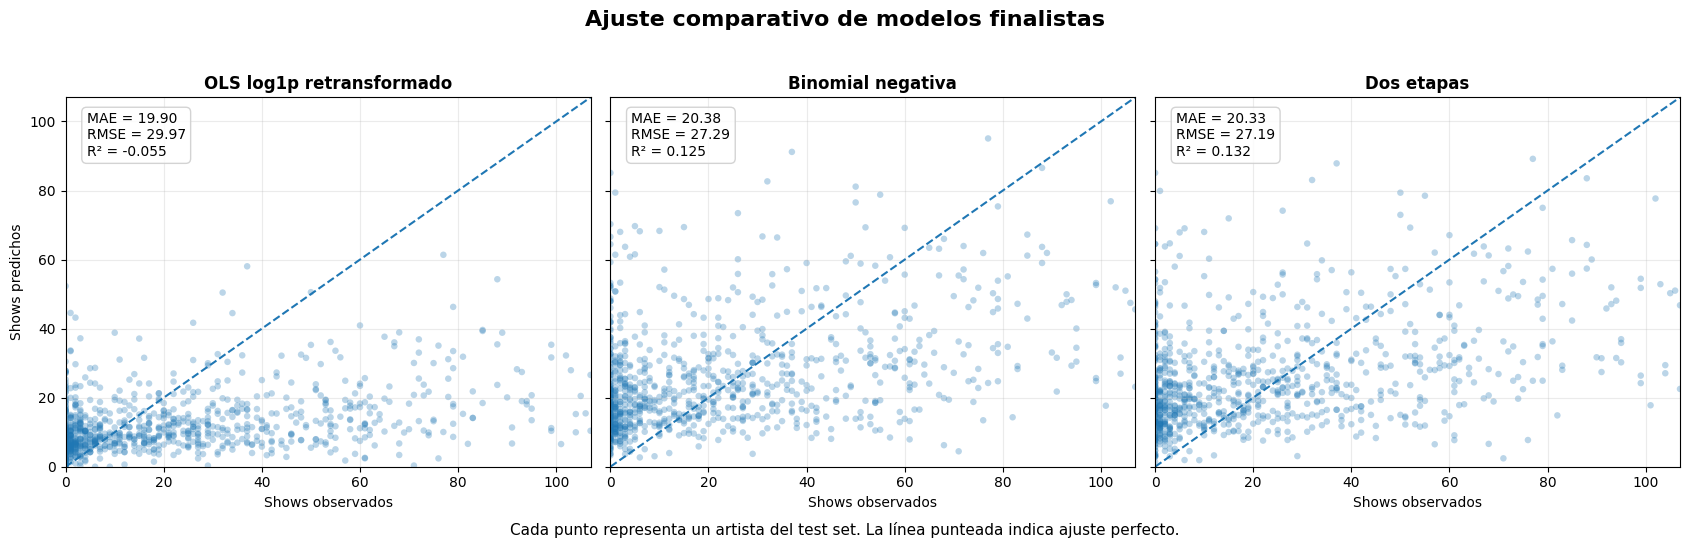

Gráfico guardado en: graficos\comparacion_observado_predicho_modelos_finalistas.png


In [49]:
# ============================================================
# Gráfico observado versus predicho para modelos finalistas
# ============================================================

import matplotlib.pyplot as plt
import numpy as np
import os

directorio_graficos = "graficos"

os.makedirs(directorio_graficos, exist_ok=True)

limite_ejes = np.percentile(
    pd.concat(
        [
            predicciones_finalistas["observado"],
            predicciones_finalistas["predicho"]
        ]
    ),
    99
)

modelos_orden = [
    "OLS log1p retransformado",
    "Binomial negativa",
    "Dos etapas"
]

fig, axes = plt.subplots(
    nrows=1,
    ncols=3,
    figsize=(17, 5),
    sharex=True,
    sharey=True
)

for ax, nombre_modelo_grafico in zip(axes, modelos_orden):
    
    datos_modelo = predicciones_finalistas[
        predicciones_finalistas["modelo"] == nombre_modelo_grafico
    ].copy()
    
    ax.scatter(
        datos_modelo["observado"],
        datos_modelo["predicho"],
        alpha=0.30,
        s=22,
        edgecolors="none"
    )
    
    ax.plot(
        [0, limite_ejes],
        [0, limite_ejes],
        linewidth=1.5,
        linestyle="--"
    )
    
    metricas_modelo = tabla_metricas_finalistas[
        tabla_metricas_finalistas["modelo"] == nombre_modelo_grafico
    ].iloc[0]
    
    texto_metricas = (
        f"MAE = {metricas_modelo['mae_test_count']:.2f}\n"
        f"RMSE = {metricas_modelo['rmse_test_count']:.2f}\n"
        f"R² = {metricas_modelo['r2_test_count']:.3f}"
    )
    
    ax.text(
        0.04,
        0.96,
        texto_metricas,
        transform=ax.transAxes,
        ha="left",
        va="top",
        fontsize=10,
        bbox=dict(
            boxstyle="round,pad=0.35",
            facecolor="white",
            alpha=0.85,
            edgecolor="0.80"
        )
    )
    
    ax.set_title(nombre_modelo_grafico, fontsize=12, weight="bold")
    ax.set_xlim(0, limite_ejes)
    ax.set_ylim(0, limite_ejes)
    ax.grid(alpha=0.25)

axes[0].set_ylabel("Shows predichos")
for ax in axes:
    ax.set_xlabel("Shows observados")

fig.suptitle(
    "Ajuste comparativo de modelos finalistas",
    fontsize=16,
    weight="bold",
    y=1.03
)

fig.text(
    0.5,
    -0.02,
    "Cada punto representa un artista del test set. La línea punteada indica ajuste perfecto.",
    ha="center",
    fontsize=11
)

plt.tight_layout()

archivo_grafico_ajuste_finalistas = os.path.join(
    directorio_graficos,
    "comparacion_observado_predicho_modelos_finalistas.png"
)

plt.savefig(
    archivo_grafico_ajuste_finalistas,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Gráfico guardado en:", archivo_grafico_ajuste_finalistas)

In [50]:
# ============================================================
# Análisis de sensibilidad con variables significativas
# No reemplaza al modelo conceptual principal
# ============================================================

variables_significativas_sensibilidad = (
    tabla_significancia_finalistas
    .query(
        "familia_modelo == 'binomial_negativa_glm' "
        "and etapa == 'conteo_crudo' "
        "and significativa_005 == True "
        "and variable != 'const'"
    )["variable"]
    .tolist()
)

variables_significativas_sensibilidad = [
    variable for variable in variables_significativas_sensibilidad
    if variable in X_train_nb_finalista.columns
]

X_train_nb_sensibilidad = X_train_nb_finalista[
    ["const"] + variables_significativas_sensibilidad
].copy()

X_test_nb_sensibilidad = X_test_nb_finalista.reindex(
    columns=X_train_nb_sensibilidad.columns,
    fill_value=0
)

modelo_nb_sensibilidad = sm.GLM(
    y_train_count,
    X_train_nb_sensibilidad,
    family=sm.families.NegativeBinomial(alpha=alpha_nb_global)
).fit()

pred_nb_sensibilidad = modelo_nb_sensibilidad.predict(X_test_nb_sensibilidad)

metricas_nb_sensibilidad = calcular_metricas_conteo(
    y_test_count,
    pred_nb_sensibilidad
)

tabla_sensibilidad_significativas = pd.DataFrame([
    {
        "modelo": "NB solo variables significativas",
        "n_variables": len(variables_significativas_sensibilidad),
        "mae_test_count": metricas_nb_sensibilidad["mae_count"],
        "rmse_test_count": metricas_nb_sensibilidad["rmse_count"],
        "r2_test_count": metricas_nb_sensibilidad["r2_count"],
        "aic": modelo_nb_sensibilidad.aic,
        "bic": modelo_nb_sensibilidad.bic_llf
    }
])

display(tabla_sensibilidad_significativas.round(3))
display(modelo_nb_sensibilidad.summary())

,modelo,n_variables,mae_test_count,rmse_test_count,r2_test_count,aic,bic
0,NB solo variables significativas,13,20.285,26.871,0.152,29376.406,29463.063


<class 'statsmodels.iolib.summary.Summary'>
"""
                  Generalized Linear Model Regression Results                  
===============================================================================
Dep. Variable:     log1p_n_shows_24_25   No. Observations:                 3604
Model:                             GLM   Df Residuals:                     3590
Model Family:         NegativeBinomial   Df Model:                           13
Link Function:                     Log   Scale:                          1.0000
Method:                           IRLS   Log-Likelihood:                -14674.
Date:                 Wed, 10 Jun 2026   Deviance:                       5201.2
Time:                         16:03:29   Pearson chi2:                 3.72e+03
No. Iterations:                      9   Pseudo R-squ. (CS):             0.1943
Covariance Type:             nonrobust                                         
=========================================================================================================
                                            coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------------------
const                                     2.1215      0.089     23.932      0.000       1.948       2.295
log1p_ins_followers_imp                   0.0767      0.007     11.377      0.000       0.064       0.090
genre_short_Regional global              -1.3386      0.096    -13.929      0.000      -1.527      -1.150
genre_short_Hip-hop & trap               -0.7914      0.068    -11.562      0.000      -0.926      -0.657
genre_short_Latin & urban                -0.9170      0.078    -11.818      0.000      -1.069      -0.765
log1p_twitter_followers_imp               0.0259      0.004      5.761      0.000       0.017       0.035
genre_short_Pop                          -0.5031      0.061     -8.202      0.000      -0.623      -0.383
genre_short_Jazz & blues & classical     -0.8156      0.143     -5.697      0.000      -1.096      -0.535
genre_short_Electronic & dance           -0.5023      0.070     -7.158      0.000      -0.640      -0.365
genre_short_R&b, soul & funk             -0.5024      0.082     -6.119      0.000      -0.663      -0.341
major_record_label_imp_True               0.1601      0.044      3.609      0.000       0.073       0.247
country_short_imp_North America           0.4218      0.045      9.442      0.000       0.334       0.509
genre_short_Country & folk                0.2087      0.091      2.293      0.022       0.030       0.387
genre_short_Miscellaneous                -0.6366      0.201     -3.168      0.002      -1.030      -0.243
=========================================================================================================
"""

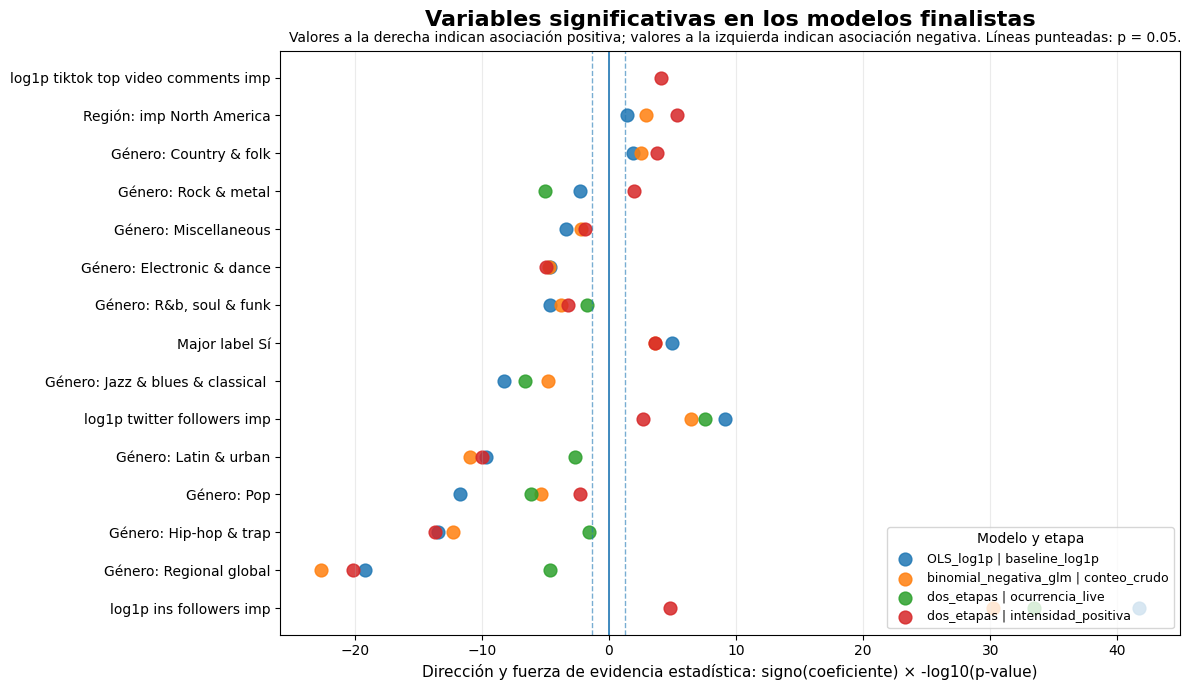

Gráfico guardado en: graficos\variables_significativas_modelos_finalistas.png


In [51]:
# ============================================================
# Gráfico de variables significativas en modelos finalistas
# Dirección del coeficiente y fuerza de evidencia estadística
# ============================================================

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import os
import textwrap

directorio_graficos = "graficos"

os.makedirs(directorio_graficos, exist_ok=True)

# ------------------------------------------------------------
# Preparación de tabla para visualización
# ------------------------------------------------------------

tabla_variables_finalistas_grafico = tabla_significancia_finalistas.copy()

tabla_variables_finalistas_grafico = tabla_variables_finalistas_grafico[
    tabla_variables_finalistas_grafico["variable"] != "const"
].copy()

tabla_variables_finalistas_grafico["modelo_etapa"] = (
    tabla_variables_finalistas_grafico["familia_modelo"]
    + " | "
    + tabla_variables_finalistas_grafico["etapa"]
)

tabla_variables_finalistas_grafico["fuerza_evidencia"] = (
    -np.log10(tabla_variables_finalistas_grafico["p_value"].clip(lower=1e-300))
)

tabla_variables_finalistas_grafico["fuerza_evidencia_con_signo"] = np.where(
    tabla_variables_finalistas_grafico["coeficiente"] >= 0,
    tabla_variables_finalistas_grafico["fuerza_evidencia"],
    -tabla_variables_finalistas_grafico["fuerza_evidencia"]
)

tabla_variables_finalistas_grafico["significativa_005"] = (
    tabla_variables_finalistas_grafico["p_value"] < 0.05
)

# ------------------------------------------------------------
# Selección de variables significativas en al menos un modelo
# ------------------------------------------------------------

variables_significativas_al_menos_un_modelo = (
    tabla_variables_finalistas_grafico
    .loc[tabla_variables_finalistas_grafico["significativa_005"], "variable"]
    .unique()
)

tabla_variables_finalistas_grafico = tabla_variables_finalistas_grafico[
    tabla_variables_finalistas_grafico["variable"].isin(variables_significativas_al_menos_un_modelo)
].copy()

# ------------------------------------------------------------
# Etiquetas legibles
# ------------------------------------------------------------

def limpiar_nombre_variable(nombre_variable):
    nombre_limpio = nombre_variable
    
    reemplazos = {
        "ins_followers_log1p": "Instagram followers",
        "twitter_followers_log1p": "Twitter/X followers",
        "tiktok_top_video_comments_log1p": "TikTok top video comments",
        "major_record_label_imp": "Major label",
        "band": "Band",
        "country_short_": "Región: ",
        "genre_short_": "Género: ",
        "pronoun_short_": "Pronombre: "
    }
    
    for texto_original, texto_nuevo in reemplazos.items():
        nombre_limpio = nombre_limpio.replace(texto_original, texto_nuevo)
    
    nombre_limpio = nombre_limpio.replace("_", " ")
    nombre_limpio = nombre_limpio.replace("True", "Sí")
    nombre_limpio = nombre_limpio.replace("False", "No")
    
    return nombre_limpio

tabla_variables_finalistas_grafico["variable_legible"] = (
    tabla_variables_finalistas_grafico["variable"]
    .apply(limpiar_nombre_variable)
)

# ------------------------------------------------------------
# Orden de modelos y variables
# ------------------------------------------------------------

orden_modelos_etapas = [
    "OLS_log1p | baseline_log1p",
    "binomial_negativa_glm | conteo_crudo",
    "dos_etapas | ocurrencia_live",
    "dos_etapas | intensidad_positiva"
]

tabla_variables_finalistas_grafico["modelo_etapa"] = pd.Categorical(
    tabla_variables_finalistas_grafico["modelo_etapa"],
    categories=orden_modelos_etapas,
    ordered=True
)

orden_variables = (
    tabla_variables_finalistas_grafico
    .groupby("variable_legible")["fuerza_evidencia"]
    .max()
    .sort_values(ascending=True)
    .index
    .tolist()
)

tabla_variables_finalistas_grafico["variable_legible"] = pd.Categorical(
    tabla_variables_finalistas_grafico["variable_legible"],
    categories=orden_variables,
    ordered=True
)

# ------------------------------------------------------------
# Gráfico
# ------------------------------------------------------------

fig, ax = plt.subplots(figsize=(12, max(7, 0.36 * len(orden_variables))))

for modelo_etapa in orden_modelos_etapas:
    
    datos_modelo = tabla_variables_finalistas_grafico[
        tabla_variables_finalistas_grafico["modelo_etapa"] == modelo_etapa
    ].copy()
    
    datos_modelo = datos_modelo[datos_modelo["significativa_005"]].copy()
    
    ax.scatter(
        datos_modelo["fuerza_evidencia_con_signo"],
        datos_modelo["variable_legible"],
        s=85,
        alpha=0.85,
        label=modelo_etapa
    )

ax.axvline(0, linewidth=1.2)
ax.axvline(-1.301, linewidth=1.0, linestyle="--", alpha=0.60)
ax.axvline(1.301, linewidth=1.0, linestyle="--", alpha=0.60)

ax.set_title(
    "Variables significativas en los modelos finalistas",
    fontsize=16,
    weight="bold",
    pad=18
)

ax.set_xlabel(
    "Dirección y fuerza de evidencia estadística: signo(coeficiente) × -log10(p-value)",
    fontsize=11
)

ax.set_ylabel("")

ax.text(
    0.01,
    1.01,
    "Valores a la derecha indican asociación positiva; valores a la izquierda indican asociación negativa. Líneas punteadas: p = 0.05.",
    transform=ax.transAxes,
    ha="left",
    va="bottom",
    fontsize=10
)

ax.grid(axis="x", alpha=0.25)
ax.legend(
    title="Modelo y etapa",
    loc="lower right",
    frameon=True,
    fontsize=9,
    title_fontsize=10
)

plt.tight_layout()

archivo_grafico_variables_significativas = os.path.join(
    directorio_graficos,
    "variables_significativas_modelos_finalistas.png"
)

plt.savefig(
    archivo_grafico_variables_significativas,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Gráfico guardado en:", archivo_grafico_variables_significativas)

In [52]:
# ============================================================
# Tabla de detalle de variables significativas por modelo finalista
# ============================================================

tabla_detalle_variables_significativas = (
    tabla_significancia_finalistas
    .query("variable != 'const' and significativa_005 == True")
    .copy()
)

tabla_detalle_variables_significativas["direccion"] = np.where(
    tabla_detalle_variables_significativas["coeficiente"] >= 0,
    "positiva",
    "negativa"
)

tabla_detalle_variables_significativas = (
    tabla_detalle_variables_significativas[
        [
            "familia_modelo",
            "etapa",
            "variable",
            "direccion",
            "coeficiente",
            "p_value"
        ]
    ]
    .sort_values(["familia_modelo", "etapa", "p_value"])
    .reset_index(drop=True)
)

display(tabla_detalle_variables_significativas.round(4))

,familia_modelo,etapa,variable,direccion,coeficiente,p_value
0,OLS_log1p,baseline_log1p,log1p_ins_followers_imp,positiva,0.1124,0.0000
1,OLS_log1p,baseline_log1p,genre_short_Regional global,negativa,-1.2926,0.0000
2,OLS_log1p,baseline_log1p,genre_short_Hip-hop & trap,negativa,-0.8273,0.0000
3,OLS_log1p,baseline_log1p,genre_short_Pop,negativa,-0.7096,0.0000
4,OLS_log1p,baseline_log1p,genre_short_Latin & urban,negativa,-0.8754,0.0000
5,OLS_log1p,baseline_log1p,log1p_twitter_followers_imp,positiva,0.0327,0.0000
6,OLS_log1p,baseline_log1p,genre_short_Jazz & blues & classical,negativa,-1.0570,0.0000
7,OLS_log1p,baseline_log1p,major_record_label_imp_True,positiva,0.2333,0.0000
8,OLS_log1p,baseline_log1p,"genre_short_R&b, soul & funk",negativa,-0.5050,0.0000
9,OLS_log1p,baseline_log1p,genre_short_Electronic & dance,negativa,-0.4591,0.0000
